## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "mass_smaller_14"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [4]:
override = False
use_preds = True
save = True
show = True

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


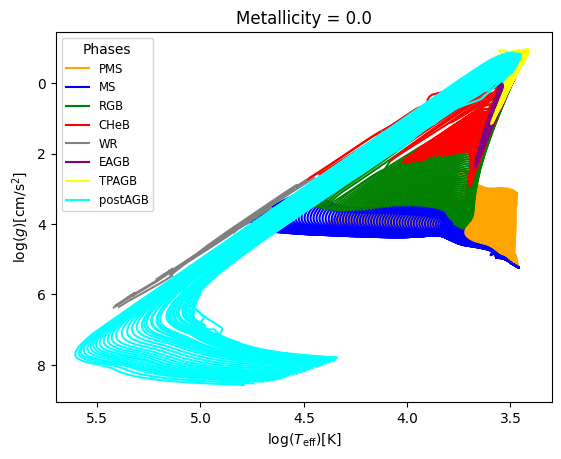

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

In [6]:
print_uniques("star_mass", iso_df)
# print_uniques_count("star_mass", iso_df)

star_mass : 1467117 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


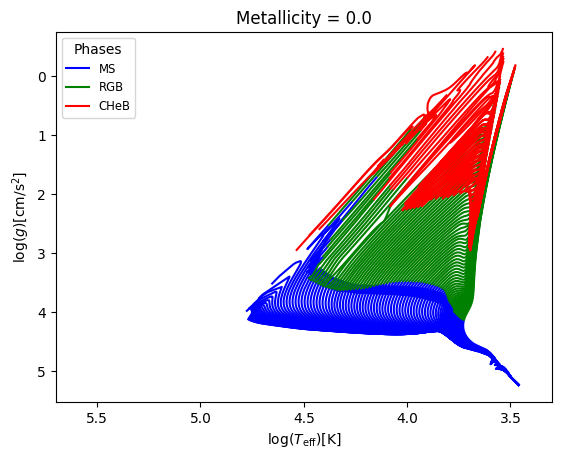

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_uniques("star_mass", phase_filtered_iso_df)
# print_uniques_count("star_mass", phase_filtered_iso_df)

star_mass : 630605 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.00,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.00,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.00,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.05,4.482577,4.350883,0.0,-0.25,12.925175,0.596074
4,5.05,4.485667,4.349692,0.0,-0.25,13.105490,0.600130
...,...,...,...,...,...,...,...
519286,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
519287,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
519288,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
519289,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


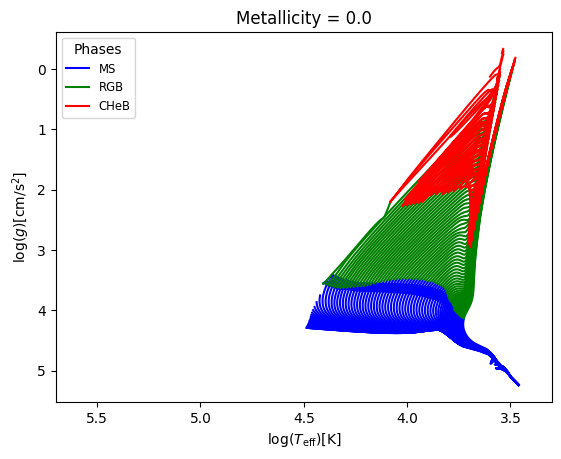

In [9]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], "star_mass" : ("<", 14)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_age_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_age_filtered.plot_Kiel([], [0.0])

In [10]:
print_all_uniques(phase_mass_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4629, Median : 8.5

log_Teff  : Range : 3.34 - 4.6345, Mean : 3.9346, Median : 3.8644

log_g  : Range : -1.08 - 5.4331, Mean : 3.5485, Median : 3.9492

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 13.9995, Mean : 3.398, Median : 2.0471

log_R  : Range : -1.0 - 3.0828, Mean : 0.6067, Median : 0.5386



In [11]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.0464342686349397
Mean value in train data for the star_mass parameter: 3.3973846370701644

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.048860774010381
Mean value in test data for the star_mass parameter: 3.399812923045874

Range in test data for the log_R parameter : -0.9974234436680278 - 3.0827540579576227
Median value in test data for the log_R parameter: 0.5398730026691951
Mean value in test data for the log_R parameter: 0.6057854356870224

(389468, 4) (129823, 4)
(38

## Model training

### Linear regression

In [12]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.703580703577132
  RMSE :  1.7944310575952438
  MAE :  1.4533067736504772
  MedAE :  1.2390292764143869
  CORR :  0.8532020075802779
  MAX_ER :  7.719467844929483
  Percentiles : 
    75th percentile :  2.0590640249930576
    90th percentile :  2.825598975577704
    95th percentile :  3.315886131132793
    99th percentile :  4.983118233497378

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.7627584839179414
  RMSE :  1.5838867857755208
  MAE :  1.0715385149713283
  MedAE :  0.7504074523781976
  CORR :  0.9184081581407212
  MAX_ER :  7.0923675864641975
  Percentiles : 
    75th percentile :  1.1937892073379053
    90th percentile :  2.3219496338030727
    95th percentile :  4.019960209972327
    99th percentile :  5.929485699387695

ma

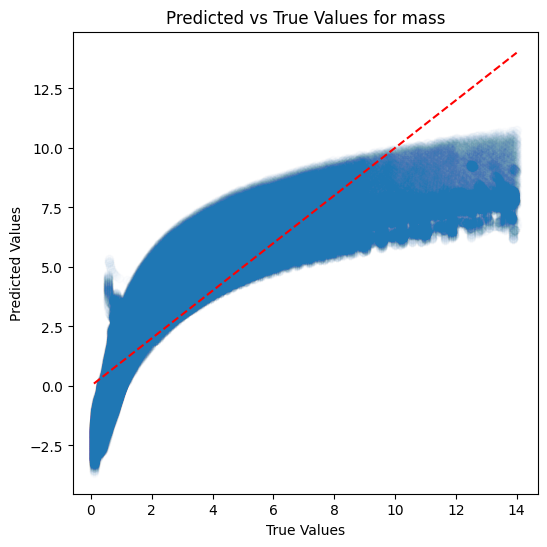

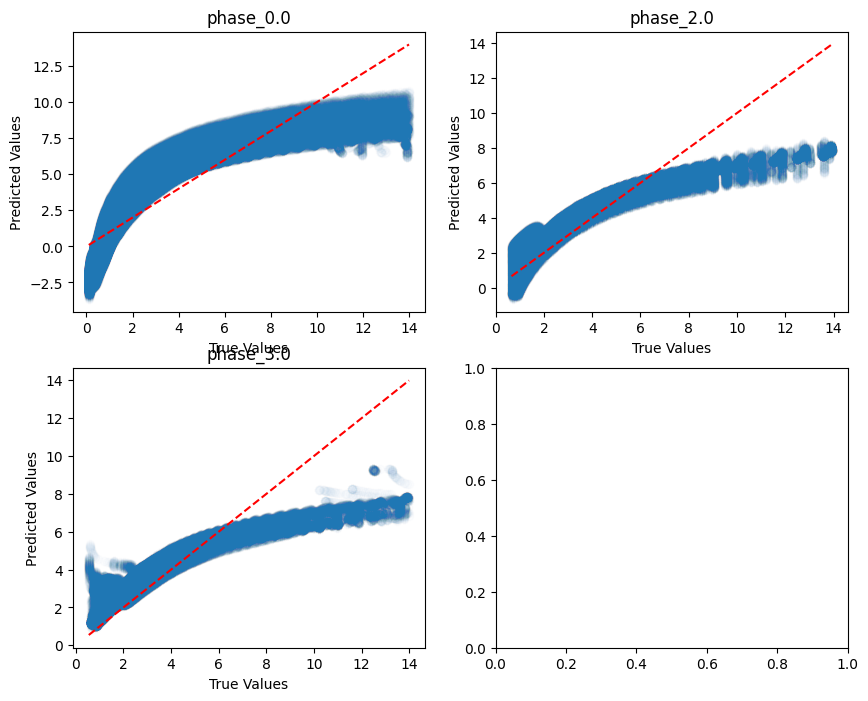

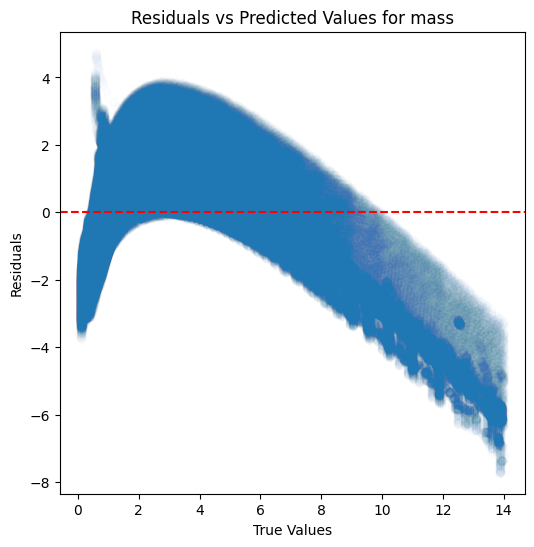

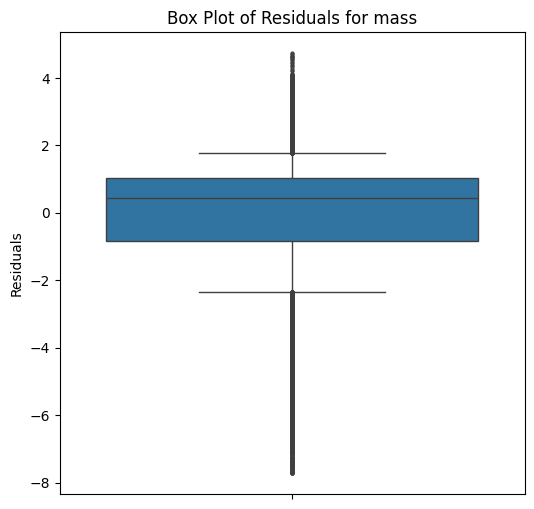

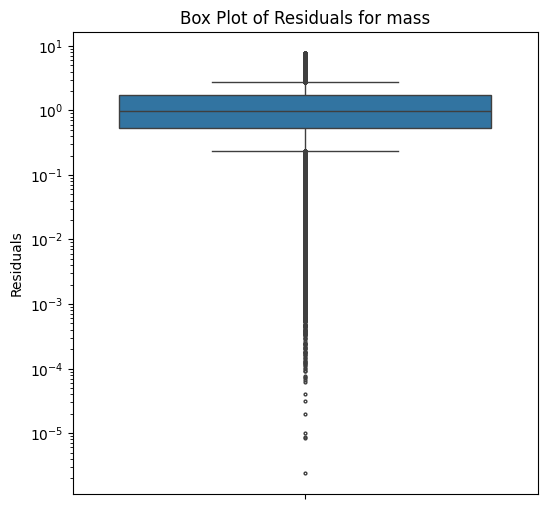

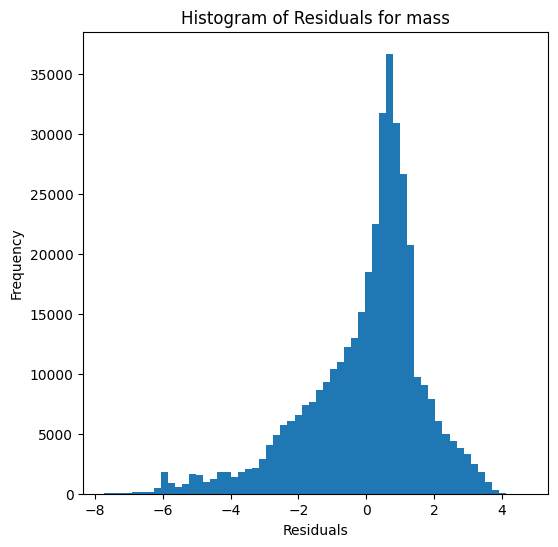

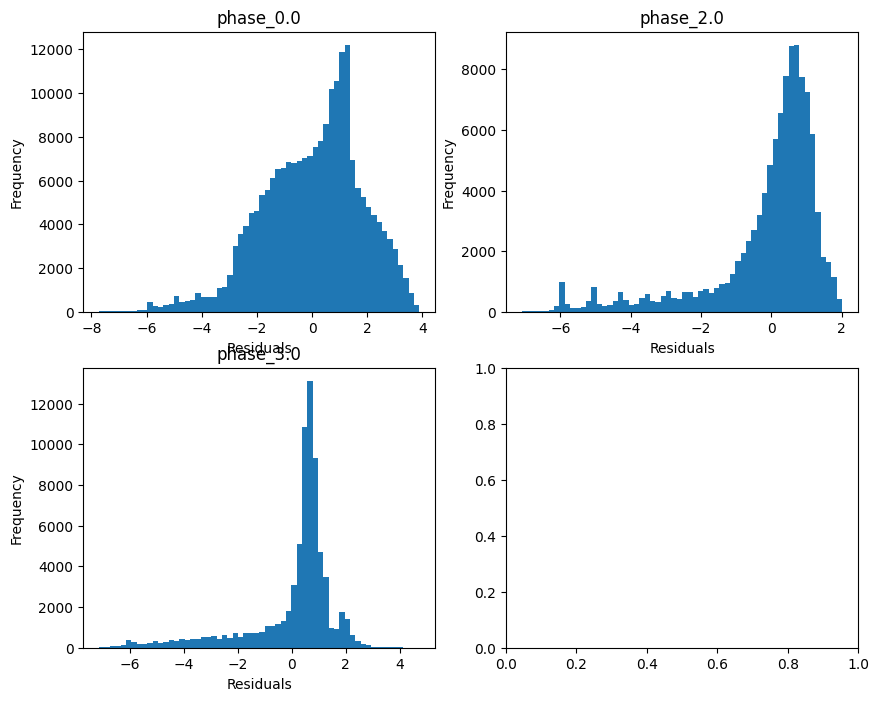

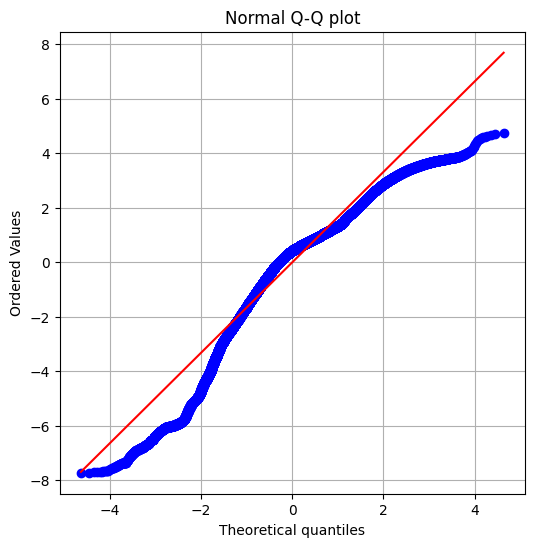

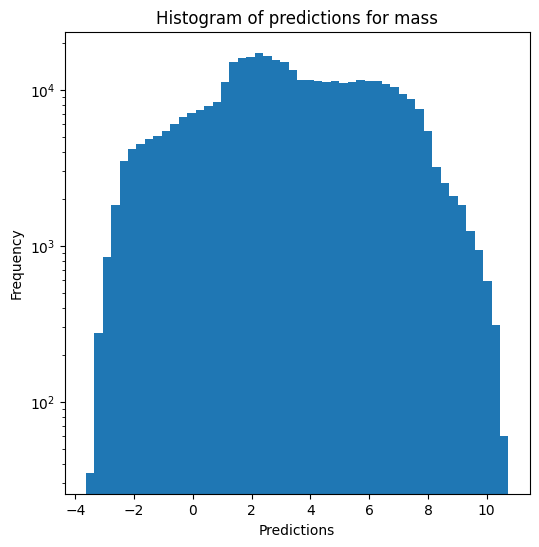

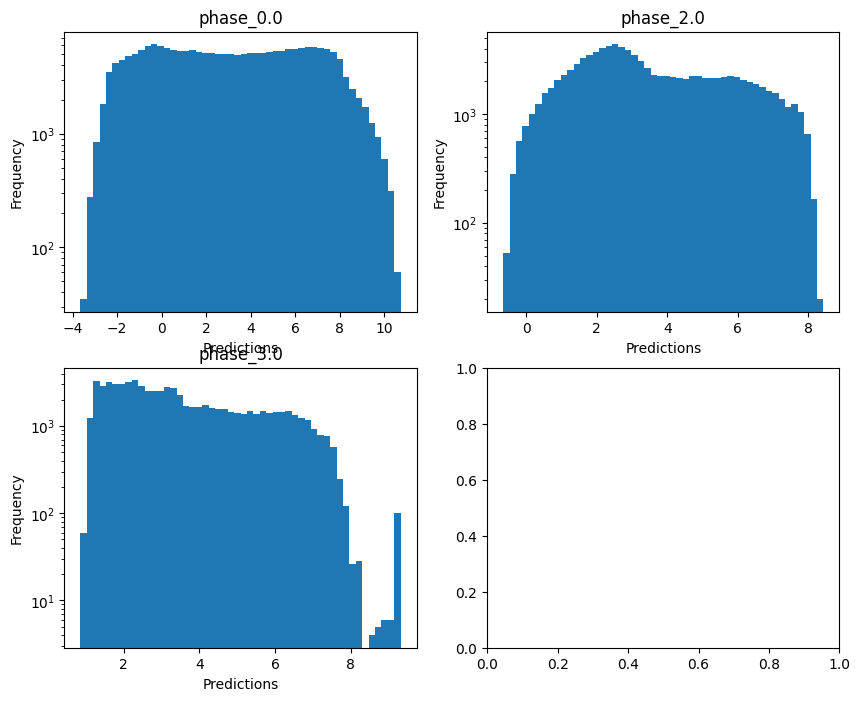

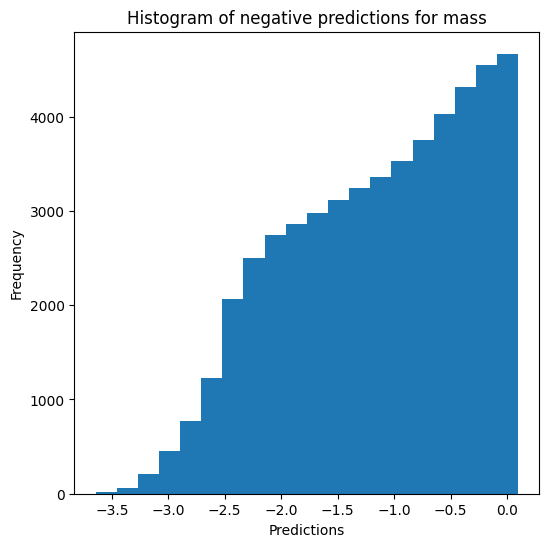


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9830496323087852
  RMSE :  0.0552032853571866
  MAE :  0.042323850048430346
  MedAE :  0.033807611390086756
  CORR :  0.9914885941715924
  MAX_ER :  0.21950730766510407
  Percentiles : 
    75th percentile :  0.06358314910866703
    90th percentile :  0.09183151165957472
    95th percentile :  0.10867394268200509
    99th percentile :  0.15558805272497508

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9806856109752665
  RMSE :  0.06618133063180101
  MAE :  0.05156292525843374
  MedAE :  0.04193665494452714
  CORR :  0.9909797904600514
  MAX_ER :  0.24910103749831736
  Percentiles : 
    75th percentile :  0.07266590465913025
    90th percentile :  0.10861353273080893
    95th percentile :  0.134499704931203
    99th percentile :  0.18544938117124676

radius results for the phase cat

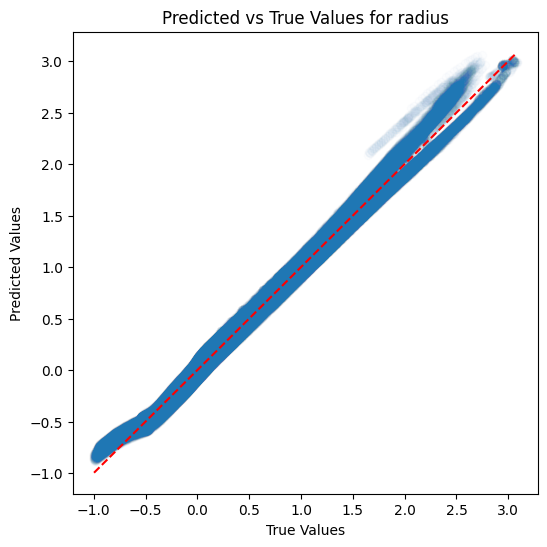

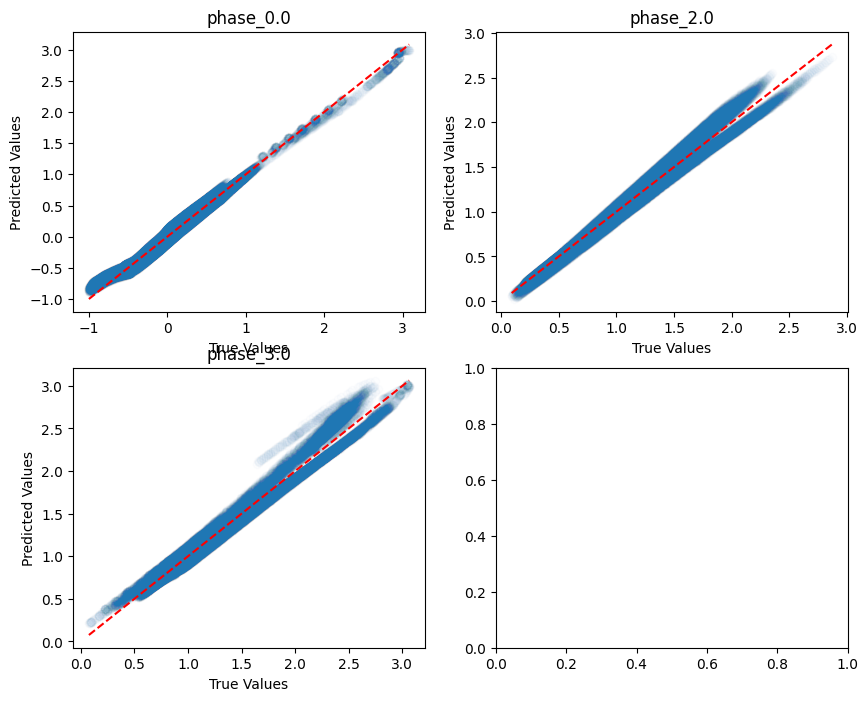

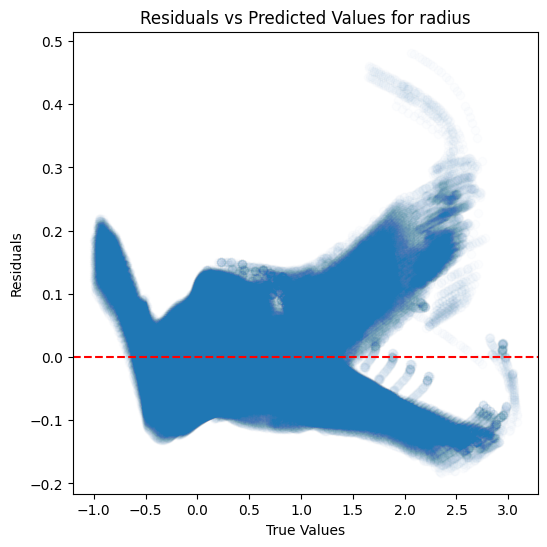

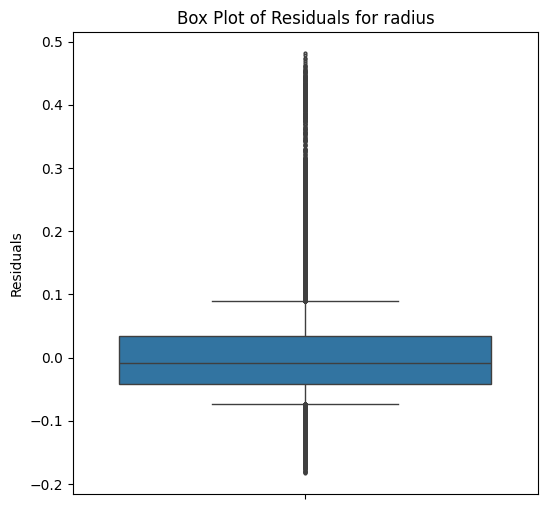

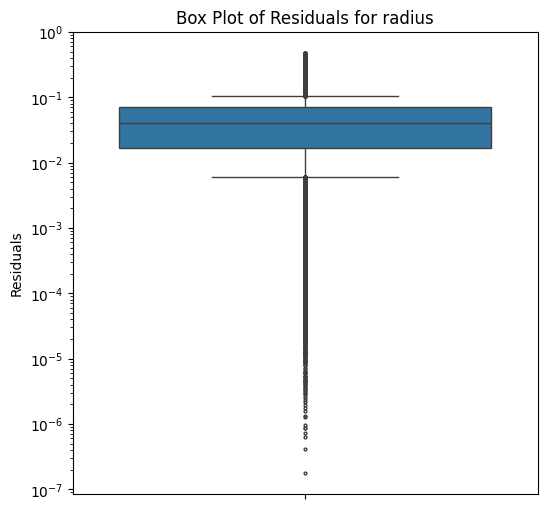

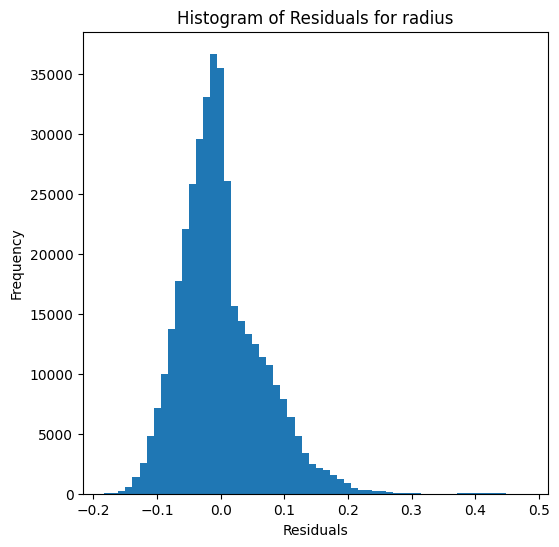

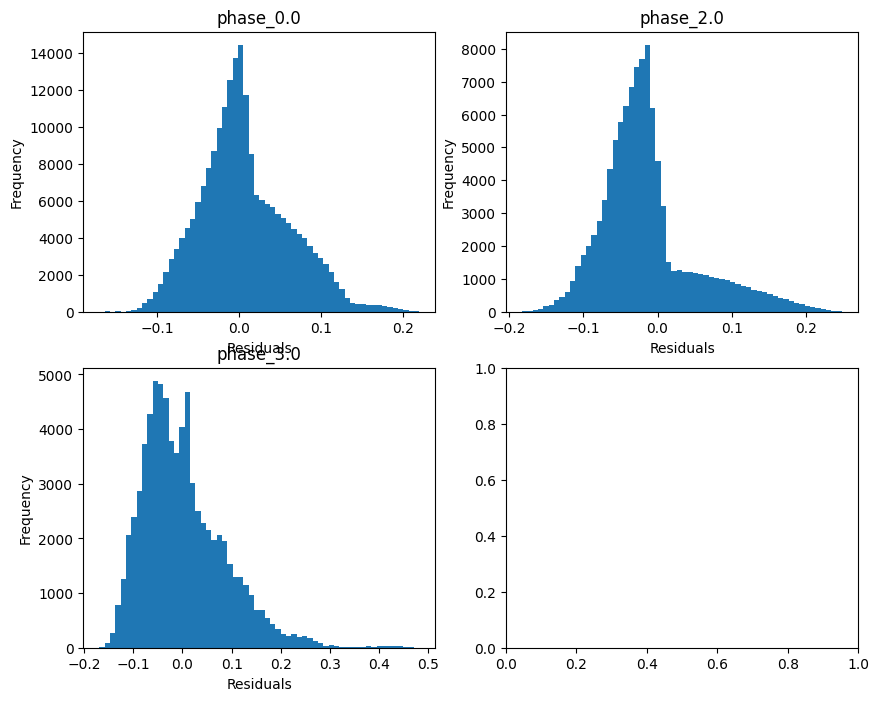

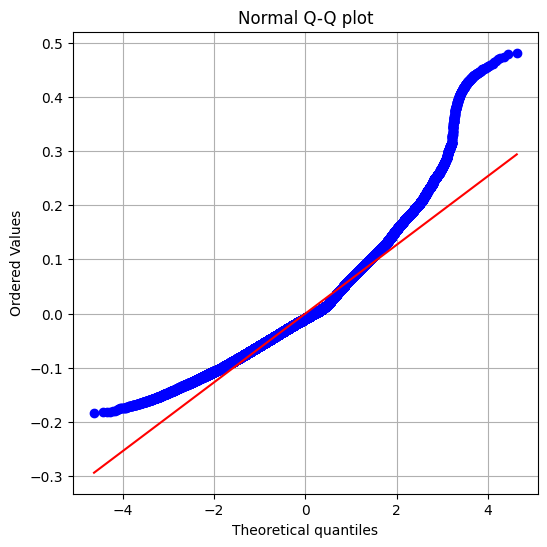

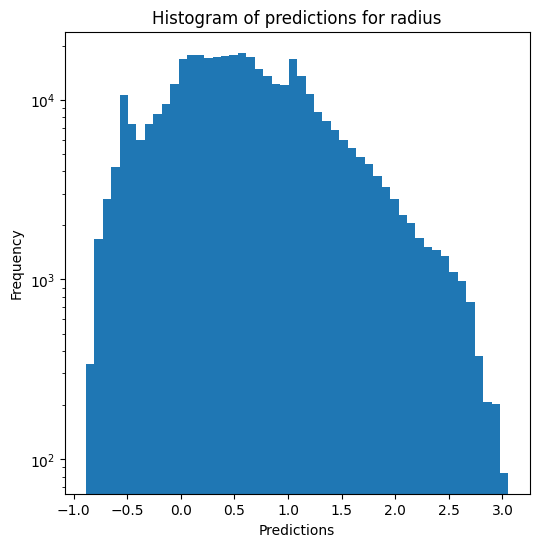

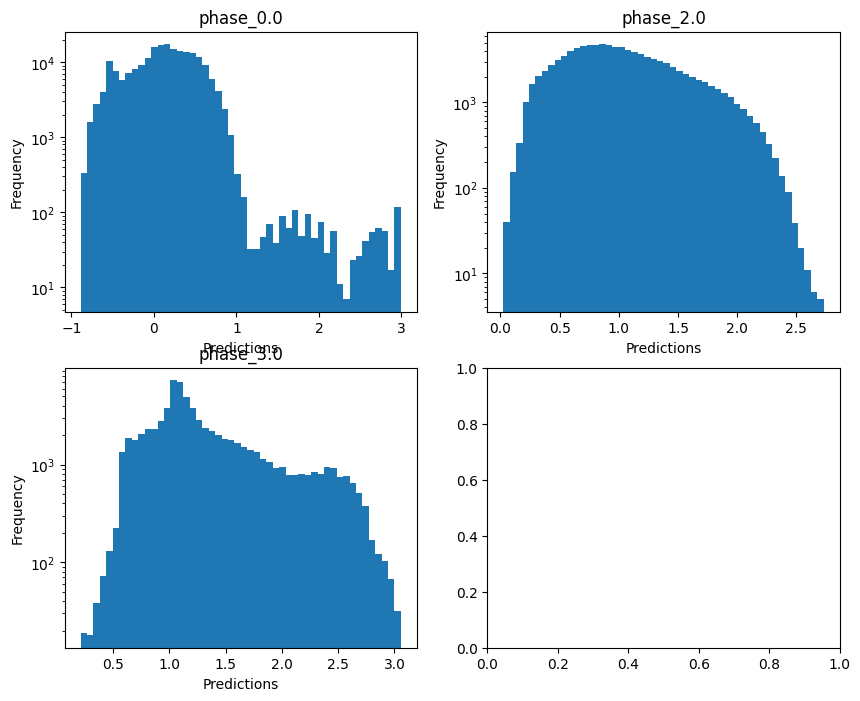

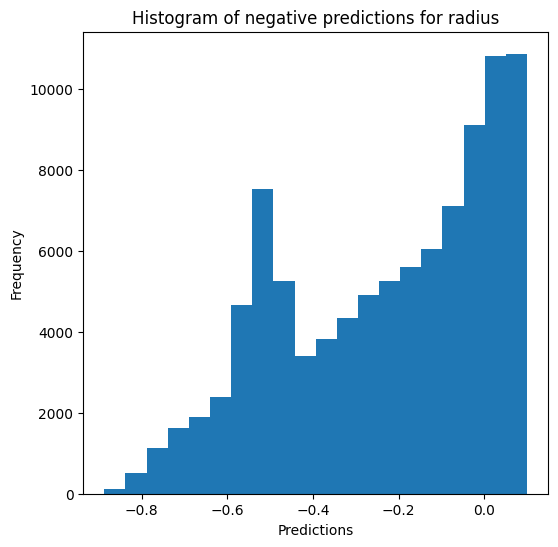

Saving results...


In [13]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) # override=True, use_preds=False

### Decision tree

In [14]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997590738023714
  RMSE :  0.05115167273909092
  MAE :  0.016920077143666445
  MedAE :  0.004116757563446816
  CORR :  0.9998795329372157
  MAX_ER :  5.116395062787612
  Percentiles : 
    75th percentile :  0.013591073320504687
    90th percentile :  0.0420684284249314
    95th percentile :  0.07391942893699761
    99th percentile :  0.19384268496181872

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999398039293963
  RMSE :  0.025210332232729196
  MAE :  0.0076804591507816595
  MedAE :  0.00032078698047710574
  CORR :  0.9999700313729203
  MAX_ER :  1.4112652929022005
  Percentiles : 
    75th percentile :  0.005696774648338121
    90th percentile :  0.023327865880685878
    95th percentile :  0.034817115784666904
    99th percen

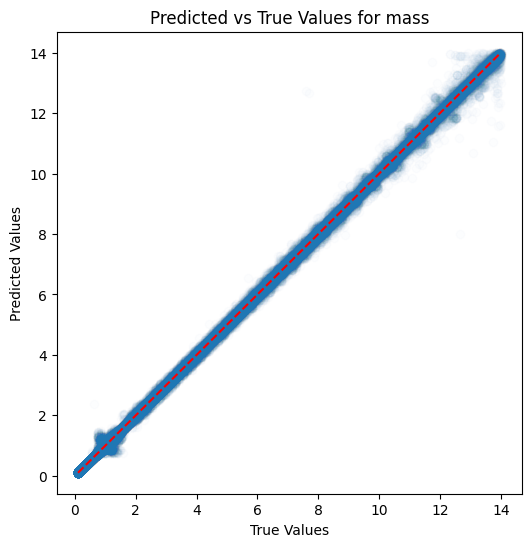

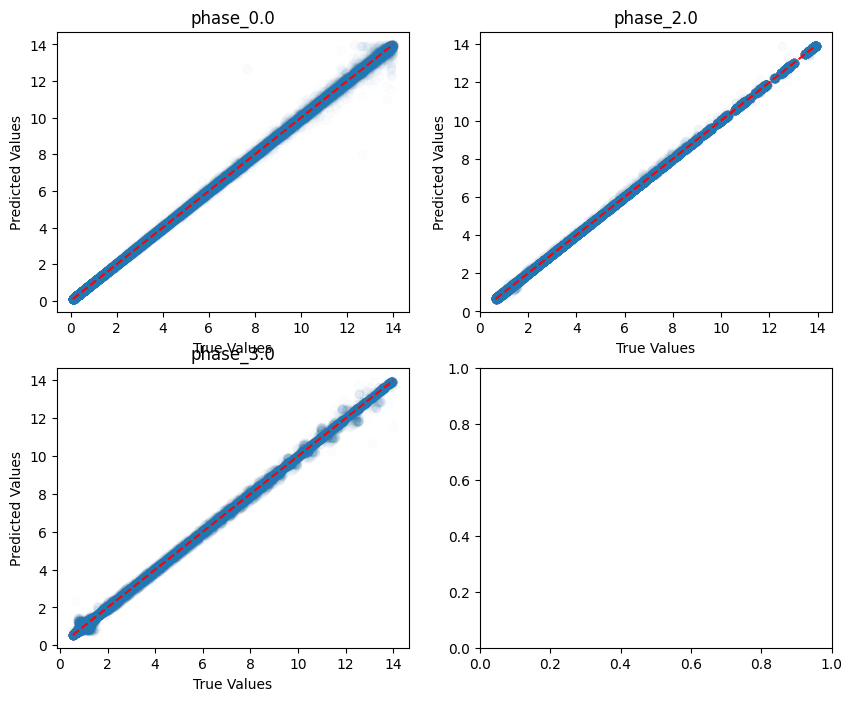

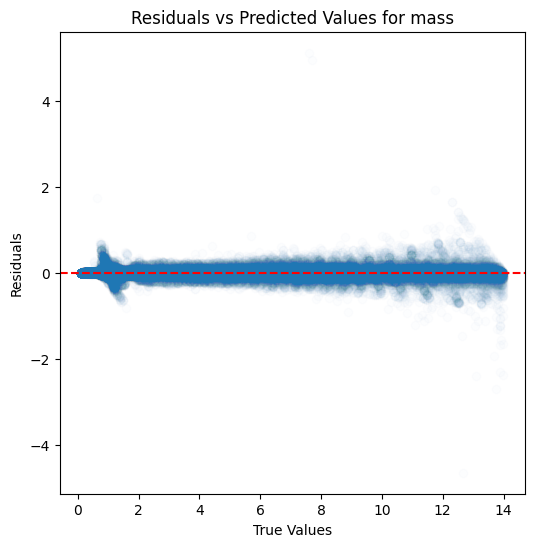

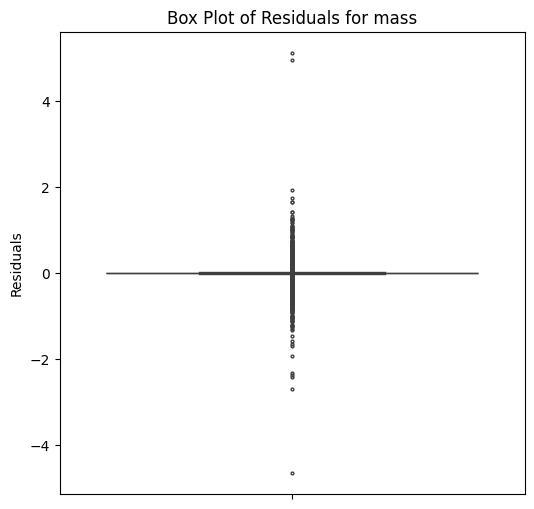

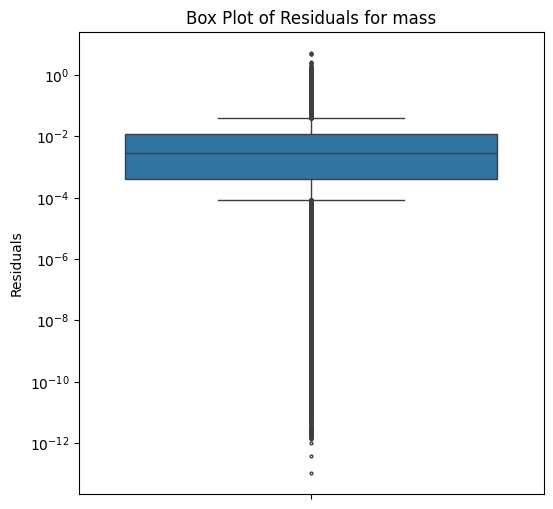

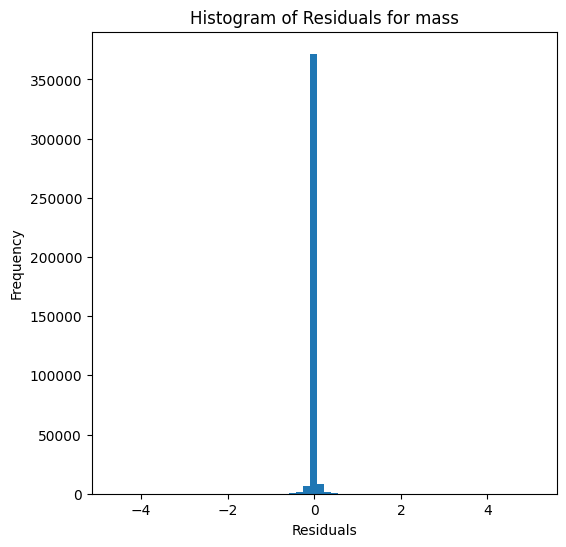

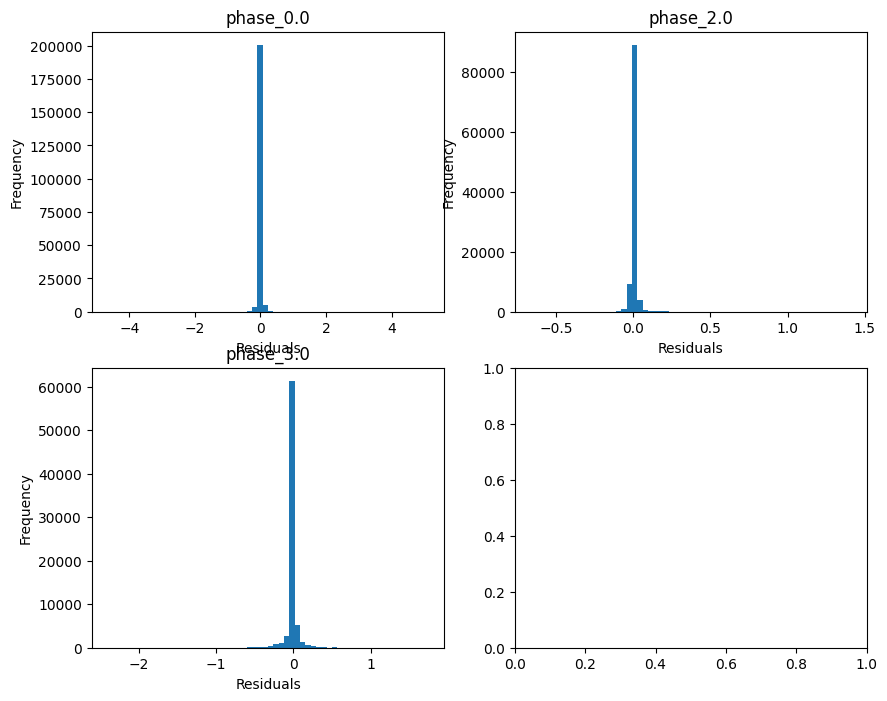

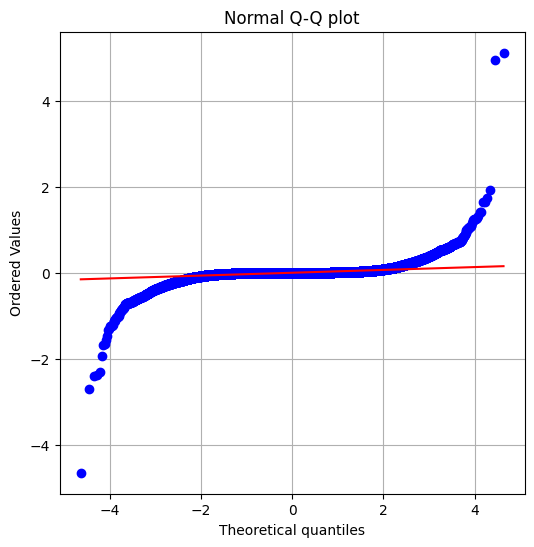

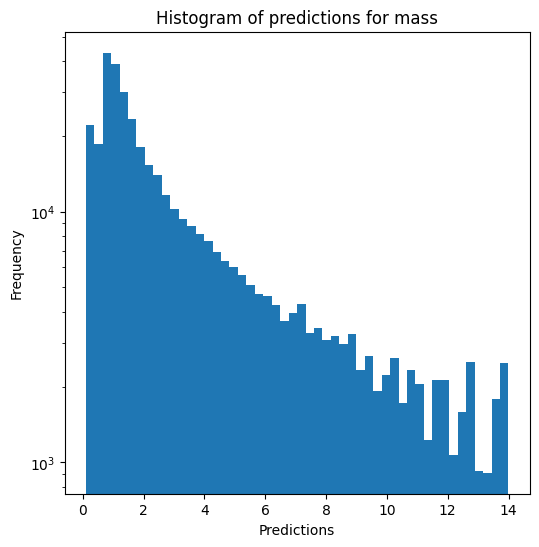

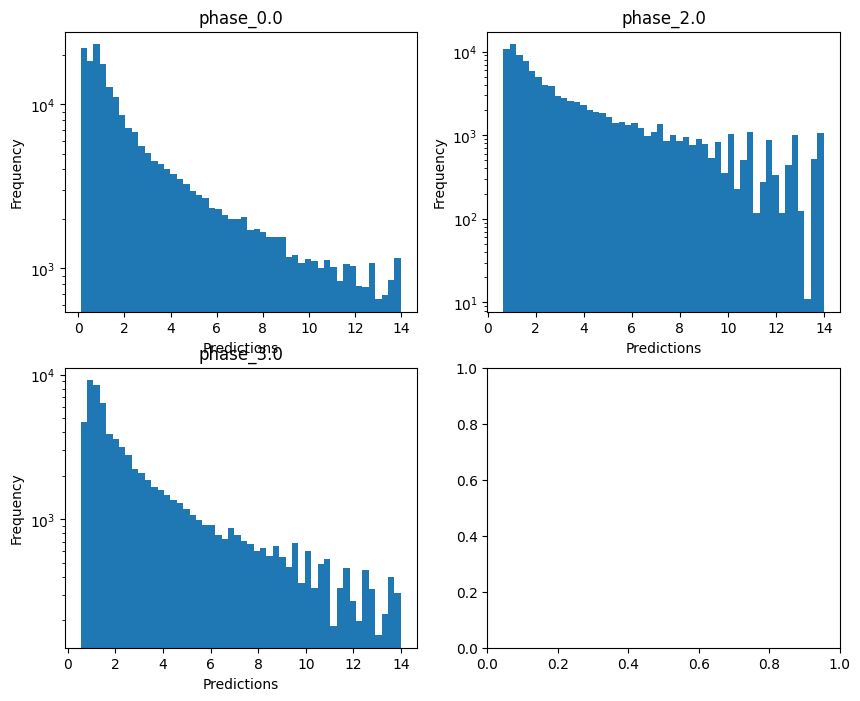

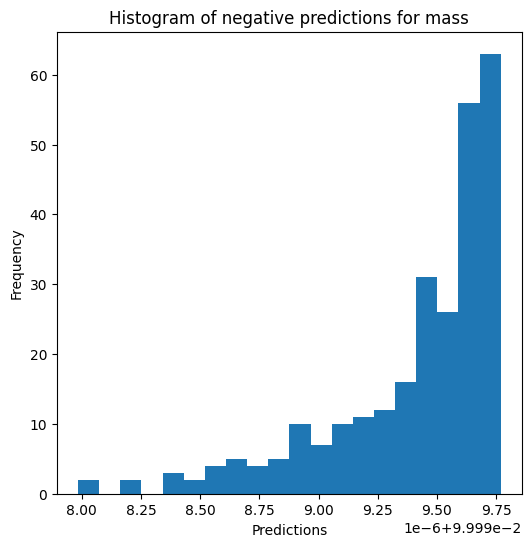


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9997880404019214
  RMSE :  0.006136779190189916
  MAE :  0.0036335192677603933
  MedAE :  0.0022789283107302882
  CORR :  0.9998940164221873
  MAX_ER :  0.31869682061915194
  Percentiles : 
    75th percentile :  0.004554576455904957
    90th percentile :  0.008044081260125908
    95th percentile :  0.011337053877062239
    99th percentile :  0.02382267823875893

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9995039197290129
  RMSE :  0.010377636576789594
  MAE :  0.007349291892801972
  MedAE :  0.006039917569692355
  CORR :  0.9997540306645297
  MAX_ER :  0.41975376919998375
  Percentiles : 
    75th percentile :  0.00984069955824643
    90th percentile :  0.013856320298751347
    95th percentile :  0.01729381333036399
    99th percentile :  0.032111272247214794

radius results for

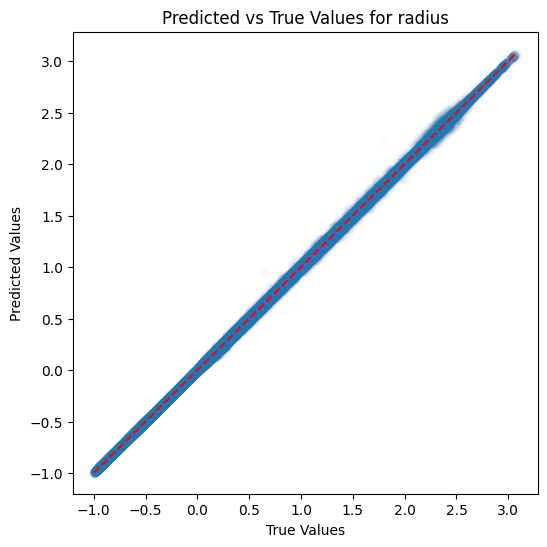

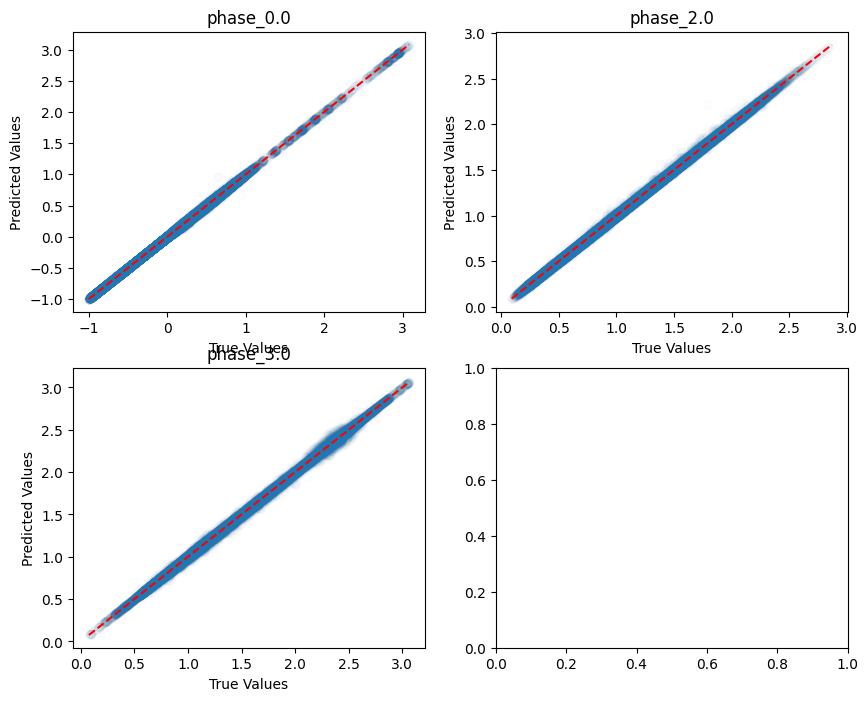

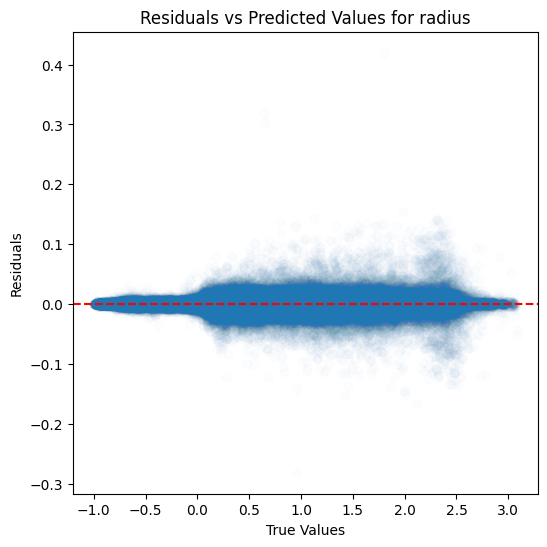

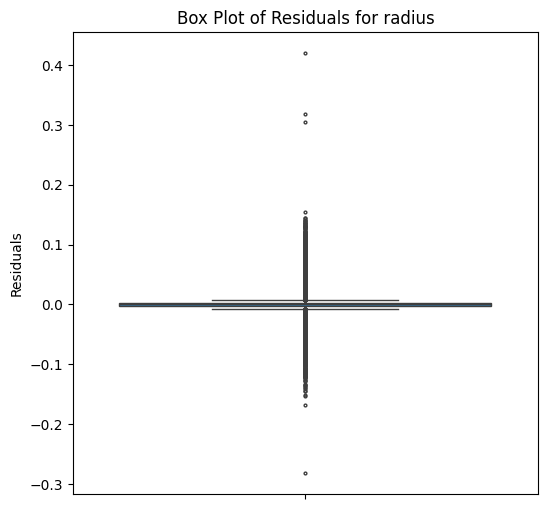

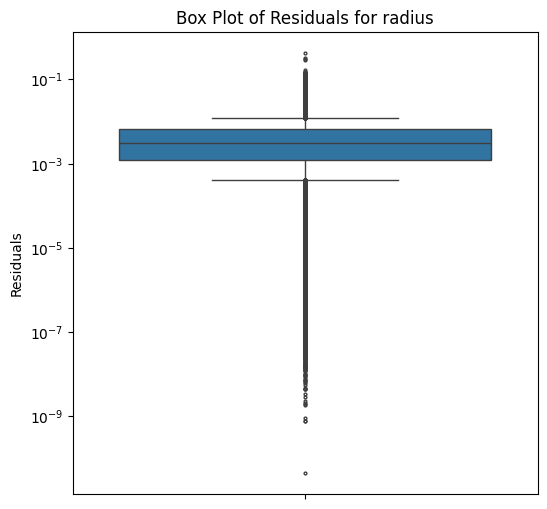

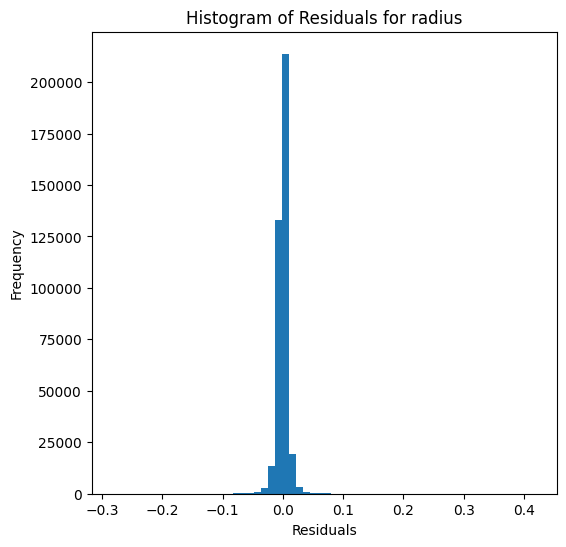

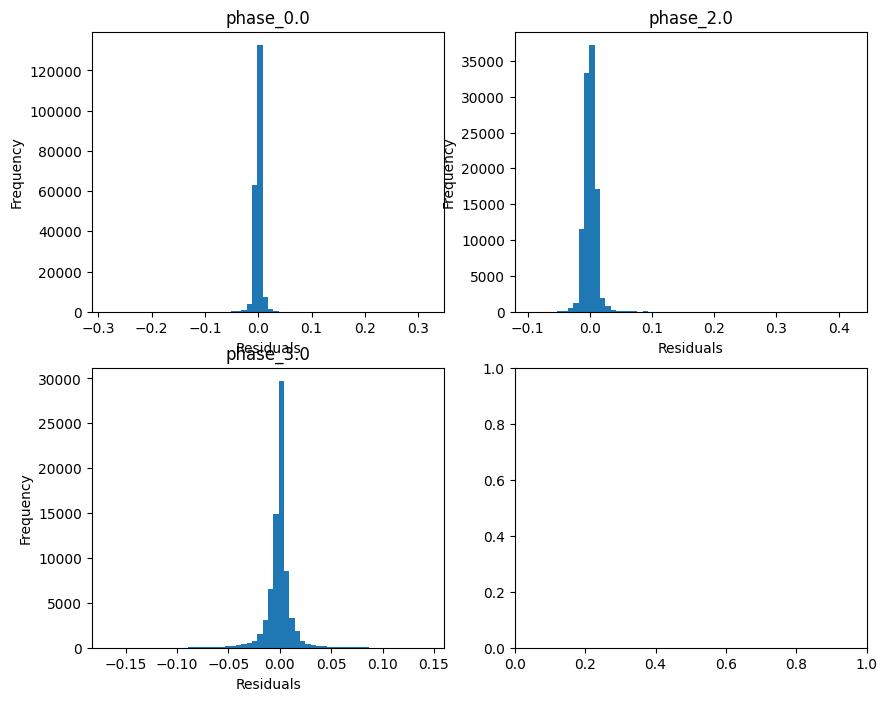

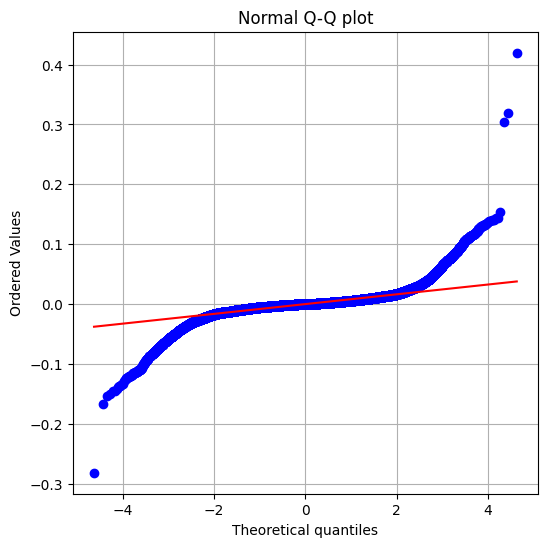

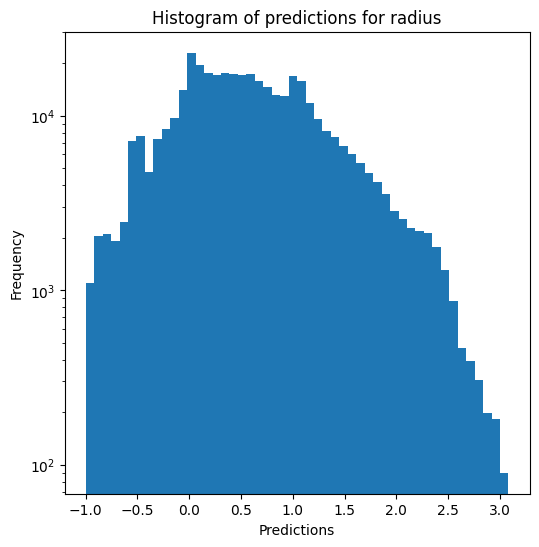

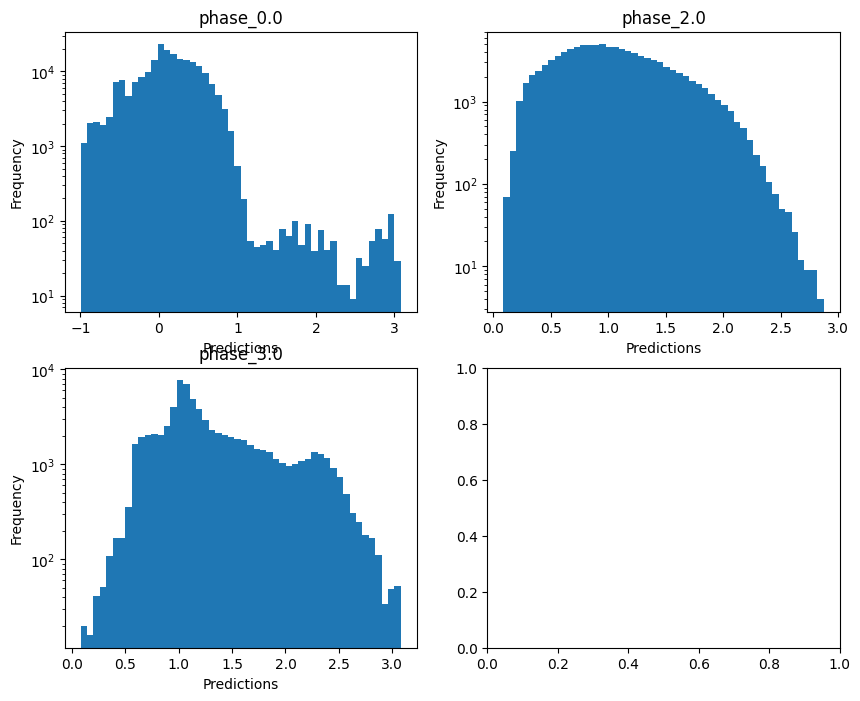

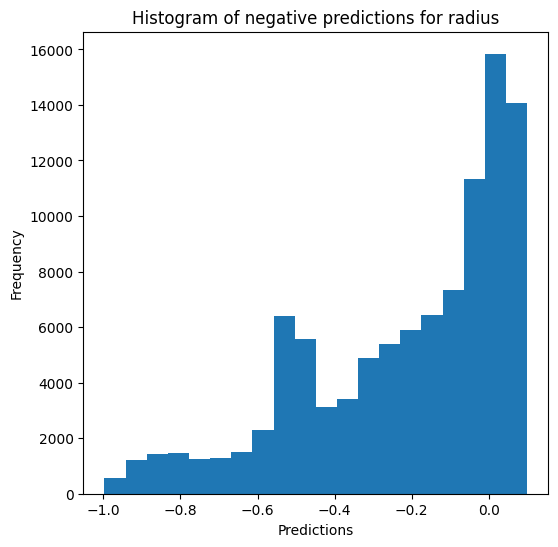

Saving results...


In [15]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### K-nearest neighbours

In [16]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9991667805594964
  RMSE :  0.09518825478725101
  MAE :  0.03086999728488882
  MedAE :  0.00712851117450064
  CORR :  0.9995923399848191
  MAX_ER :  2.603544694842226
  Percentiles : 
    75th percentile :  0.02432573294387952
    90th percentile :  0.06949621330075637
    95th percentile :  0.12413357198500667
    99th percentile :  0.38273609104831785

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997767455983123
  RMSE :  0.04854875268619234
  MAE :  0.01982376685494915
  MedAE :  0.0050826377070398165
  CORR :  0.9998883692148779
  MAX_ER :  0.9259983512345471
  Percentiles : 
    75th percentile :  0.016117742737736668
    90th percentile :  0.05505615960625533
    95th percentile :  0.10023673231264782
    

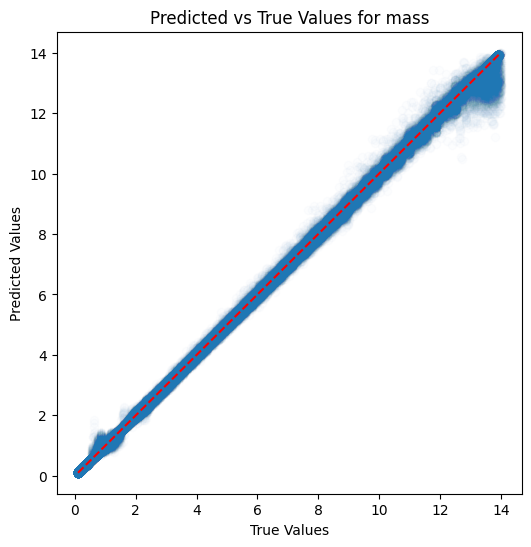

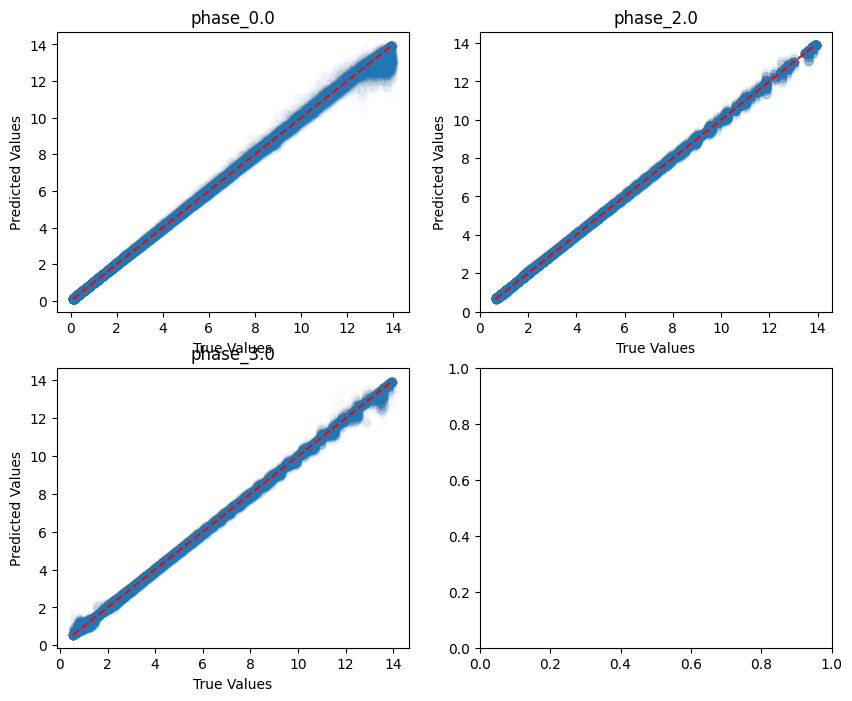

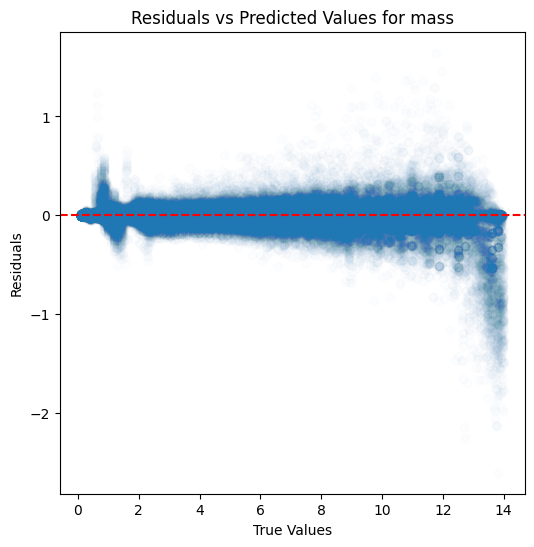

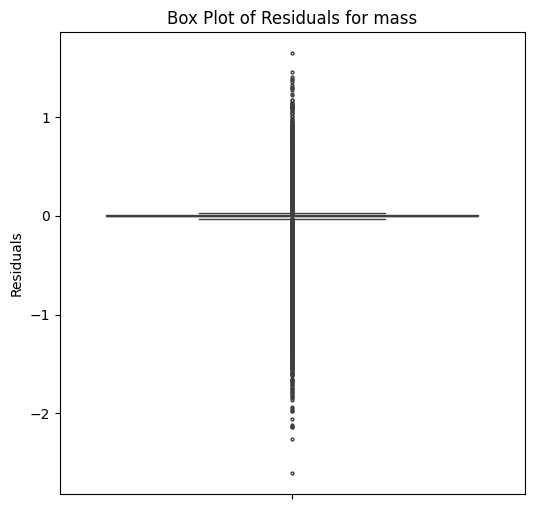

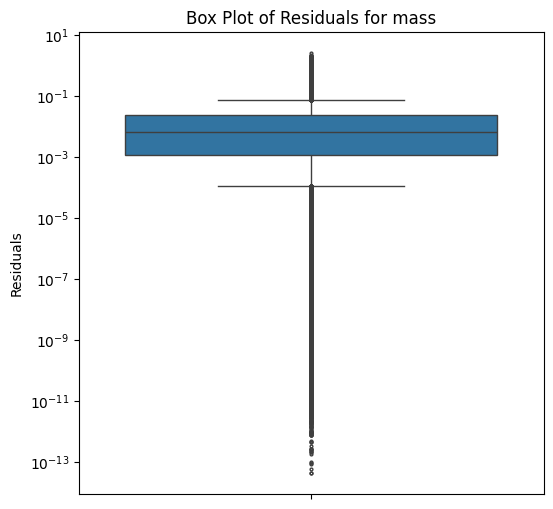

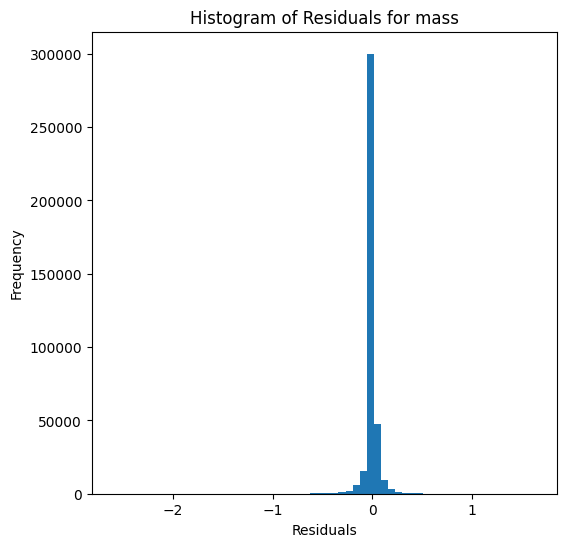

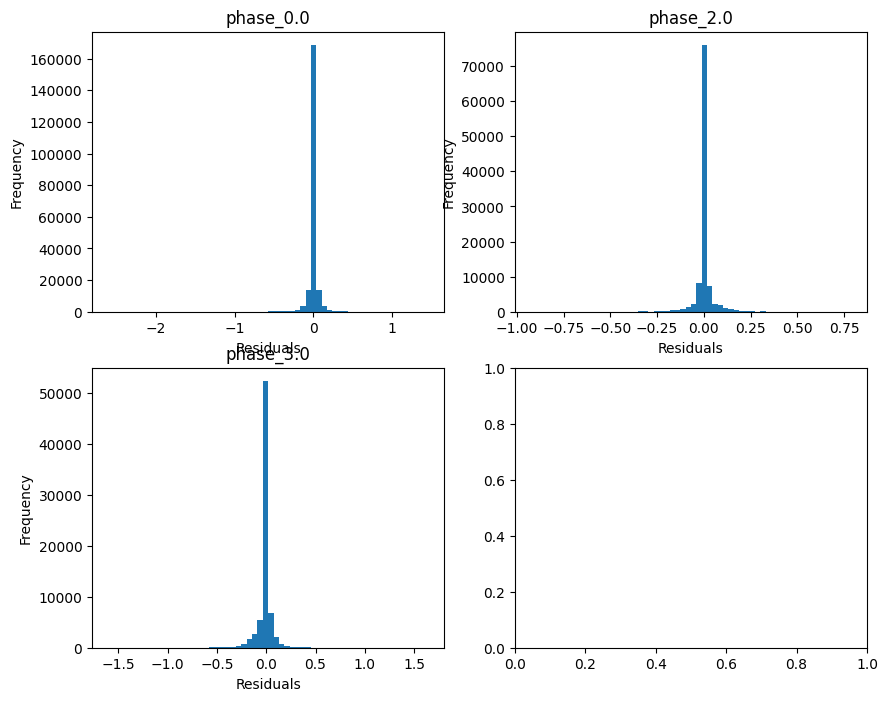

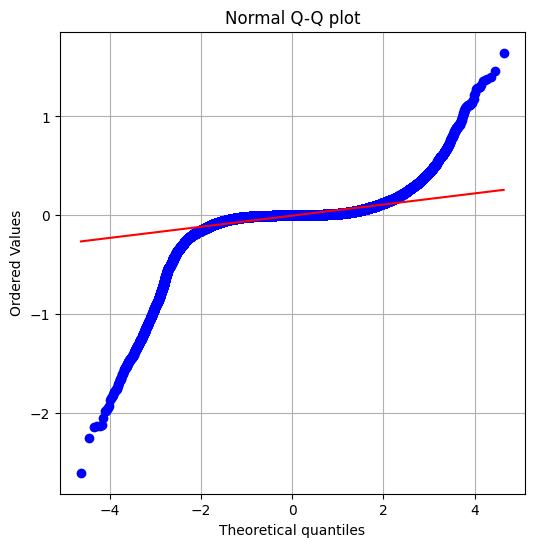

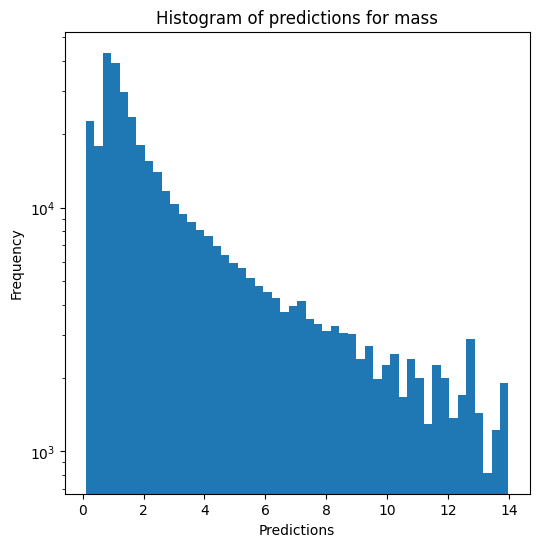

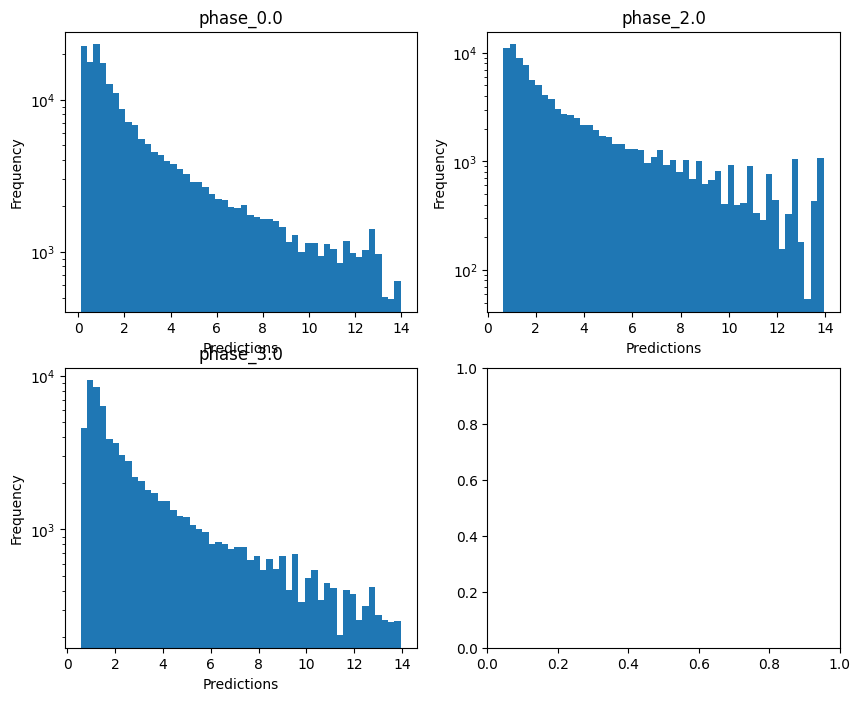


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9998255884455621
  RMSE :  0.005563455963300936
  MAE :  0.003653897706764713
  MedAE :  0.002363887293533262
  CORR :  0.9999135578590763
  MAX_ER :  0.05869663902770983
  Percentiles : 
    75th percentile :  0.004587754655073828
    90th percentile :  0.00838018740264009
    95th percentile :  0.01164102083690268
    99th percentile :  0.020960699453918586

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9998943160073213
  RMSE :  0.004787225979522919
  MAE :  0.003653502730346598
  MedAE :  0.0028593473925379587
  CORR :  0.9999471831409968
  MAX_ER :  0.0629674681983583
  Percentiles : 
    75th percentile :  0.004955175643513943
    90th percentile :  0.007933903599236937
    95th percentile :  0.009844950108033889
    99th percentile :  0.013719394681522234

radius results for 

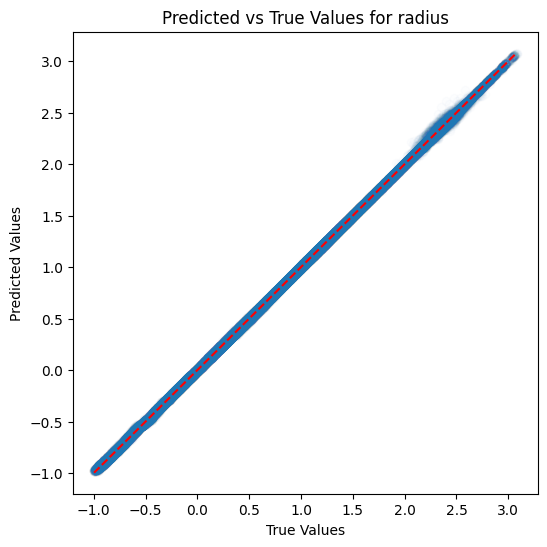

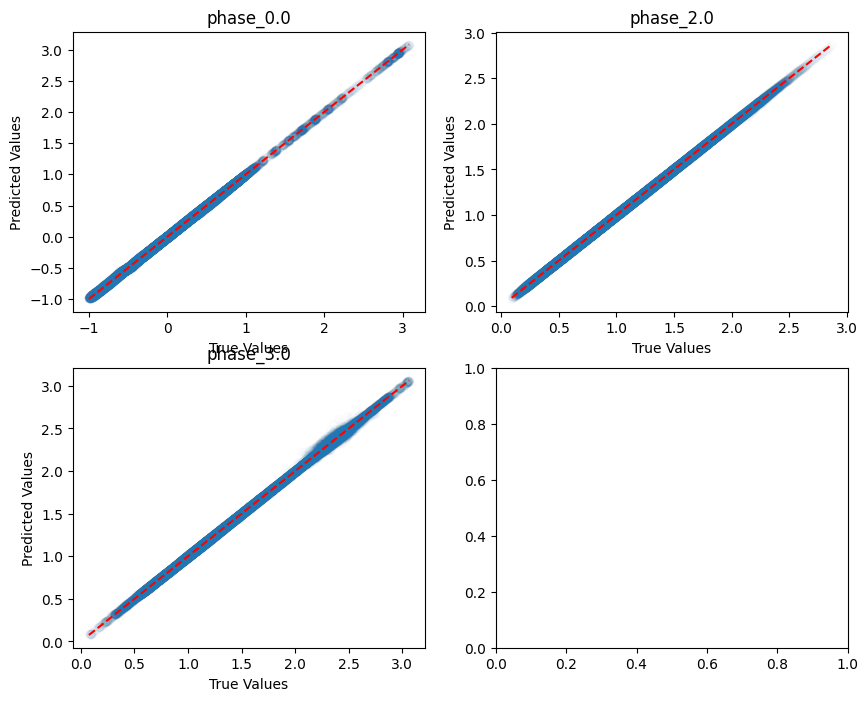

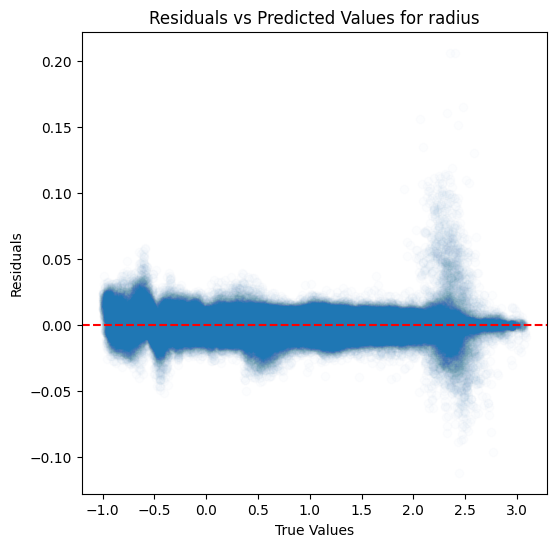

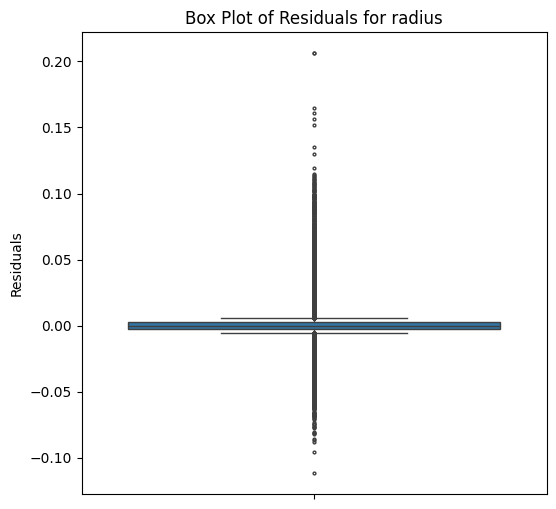

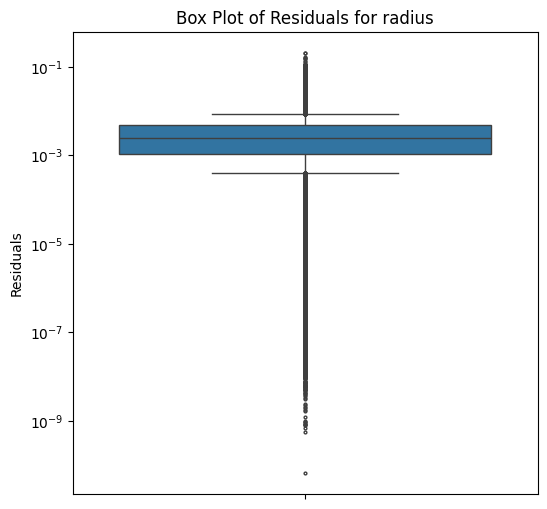

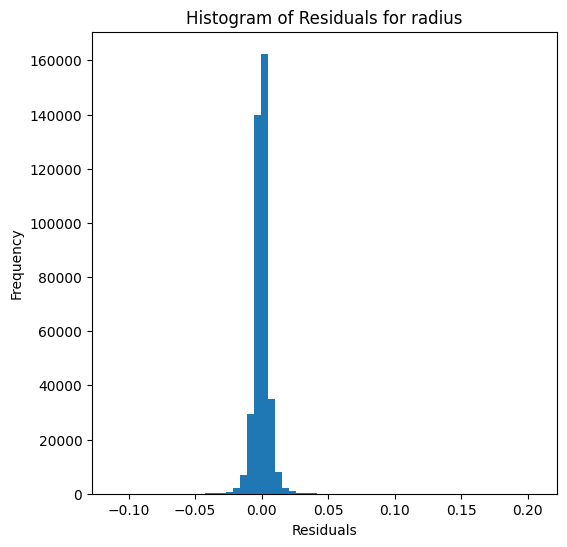

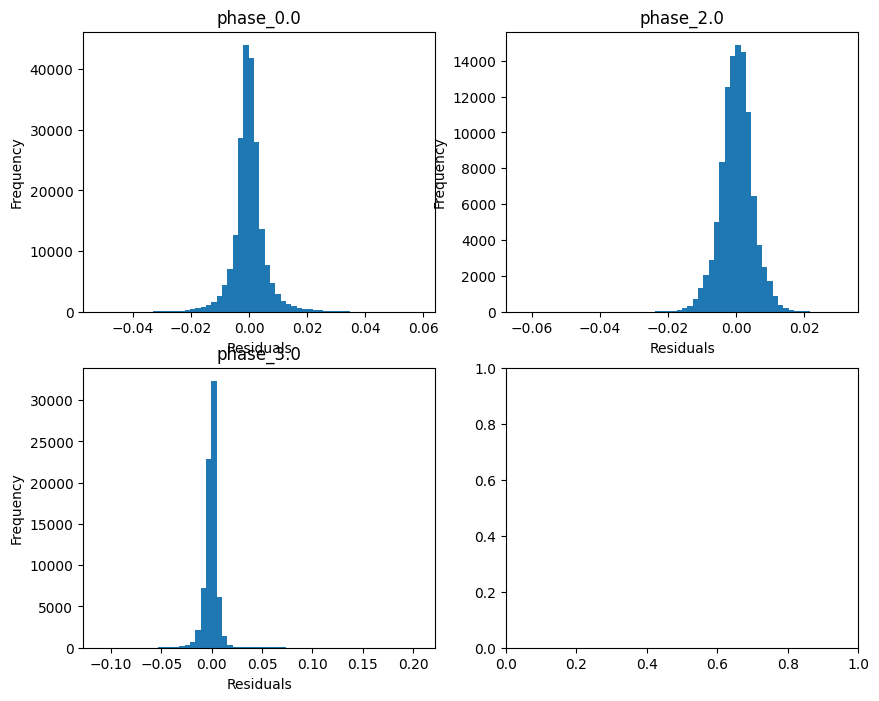

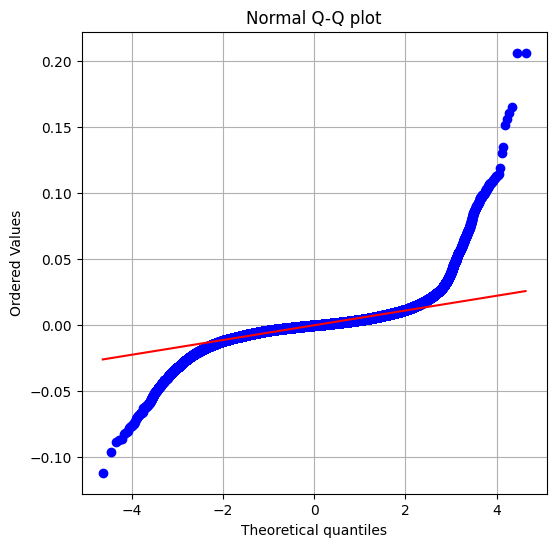

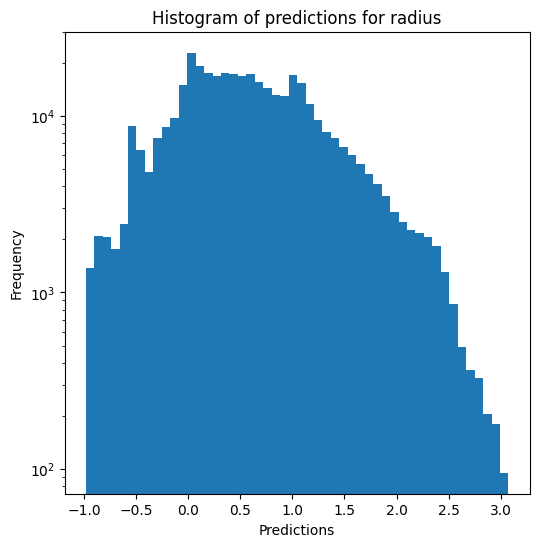

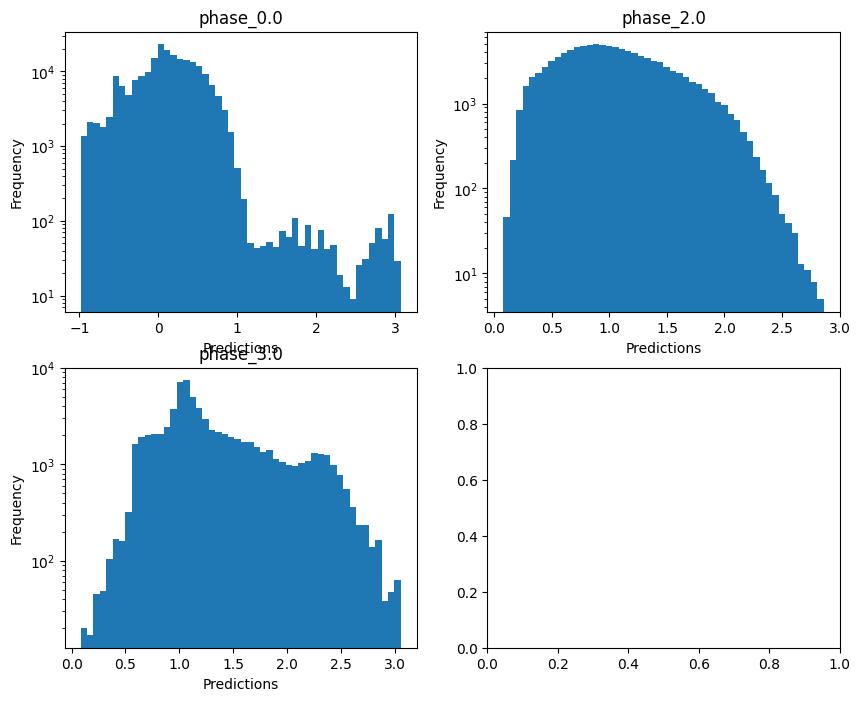

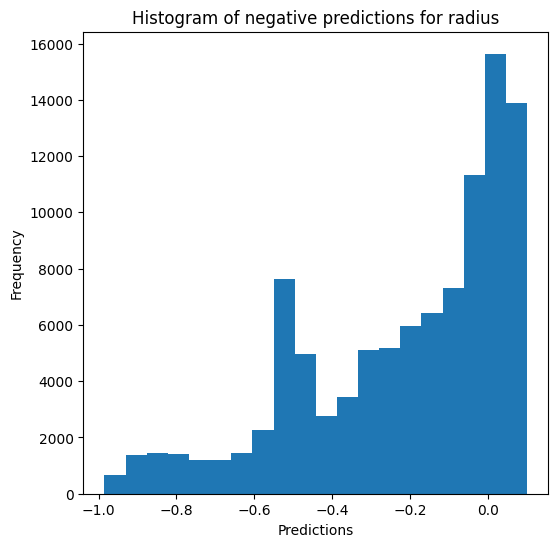

Saving results...


In [17]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### Random forests

In [18]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9999235468255409
  RMSE :  0.028815453344409887
  MAE :  0.008782410240053221
  MedAE :  0.0024326150014331027
  CORR :  0.9999617835917853
  MAX_ER :  2.3279465137664914
  Percentiles : 
    75th percentile :  0.00712815378420828
    90th percentile :  0.019620574962144668
    95th percentile :  0.034839939461777714
    99th percentile :  0.1011448180374236

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999737930935538
  RMSE :  0.01671284559554173
  MAE :  0.00842574157088346
  MedAE :  0.004369958824436249
  CORR :  0.999987052162877
  MAX_ER :  0.4834120390430403
  Percentiles : 
    75th percentile :  0.010069033634066
    90th percentile :  0.0190066271790184
    95th percentile :  0.02804341170534962
    99th percentile :  

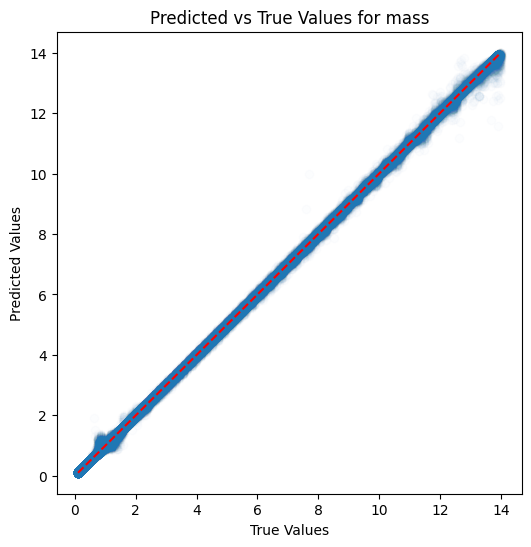

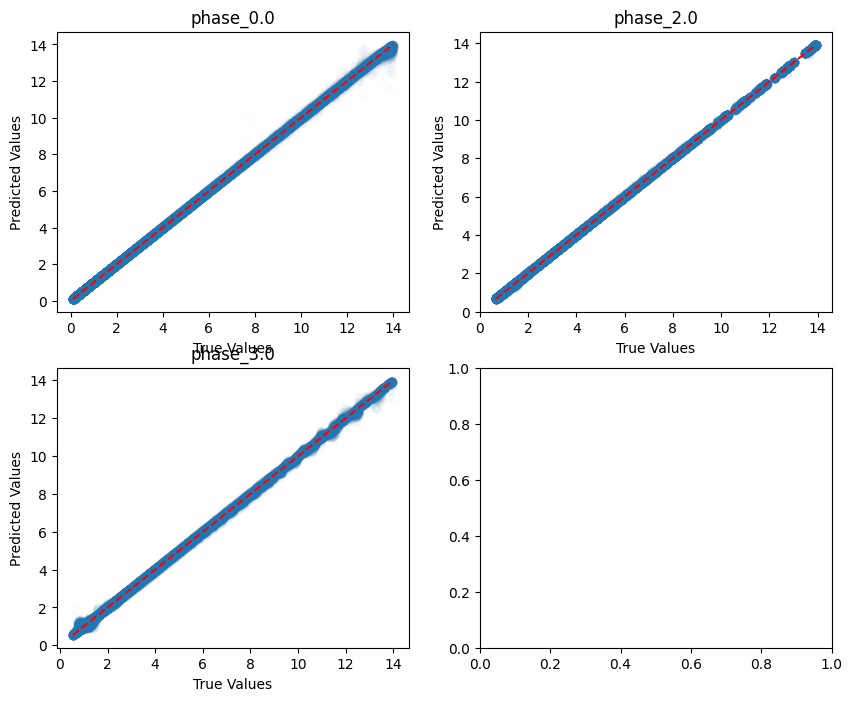

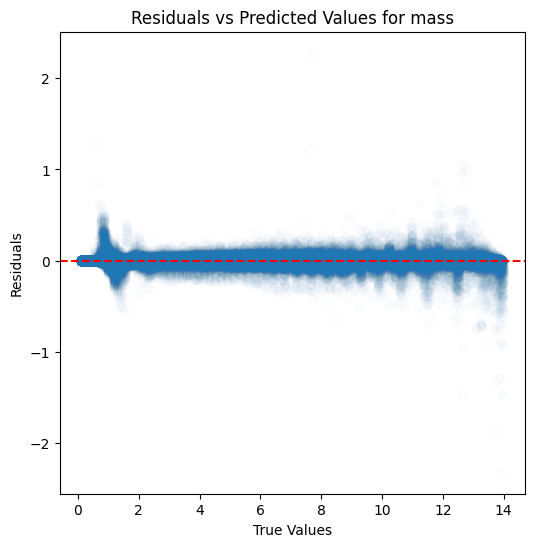

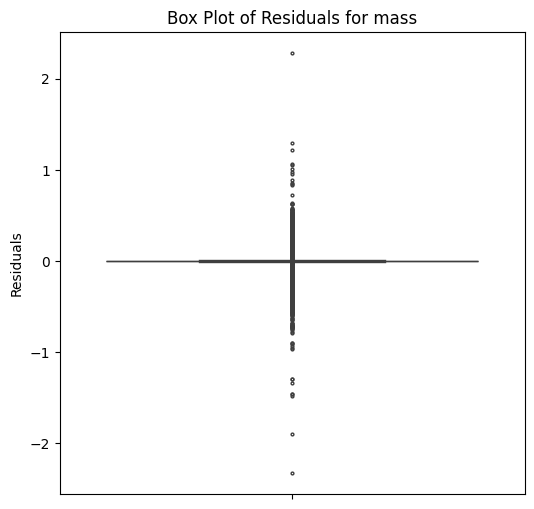

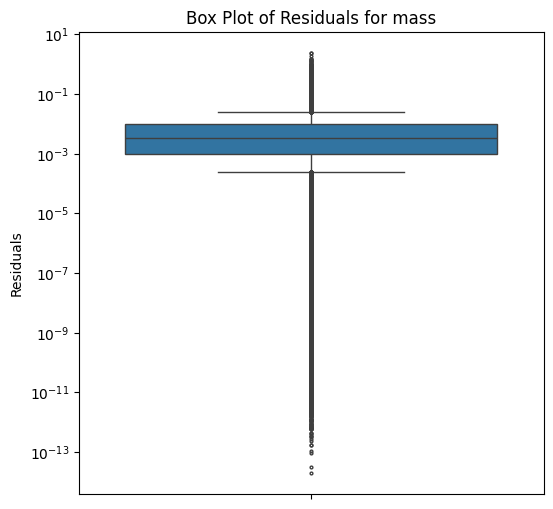

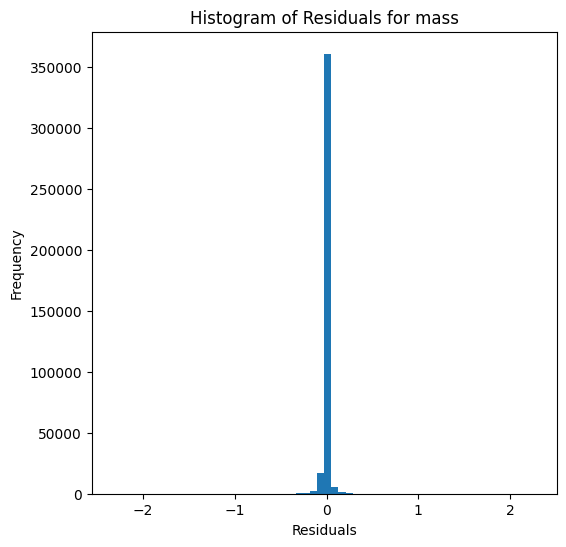

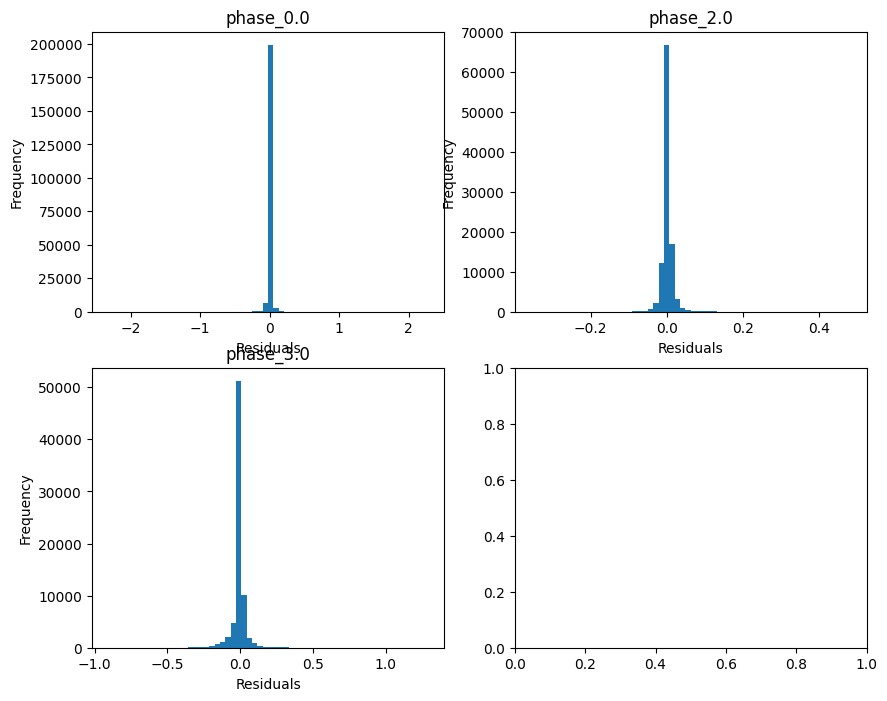

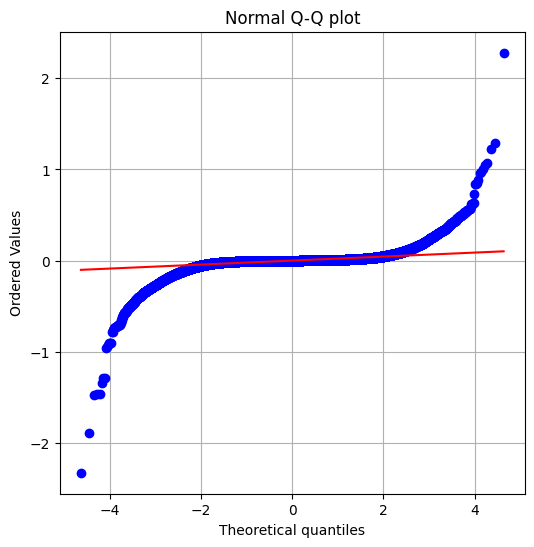

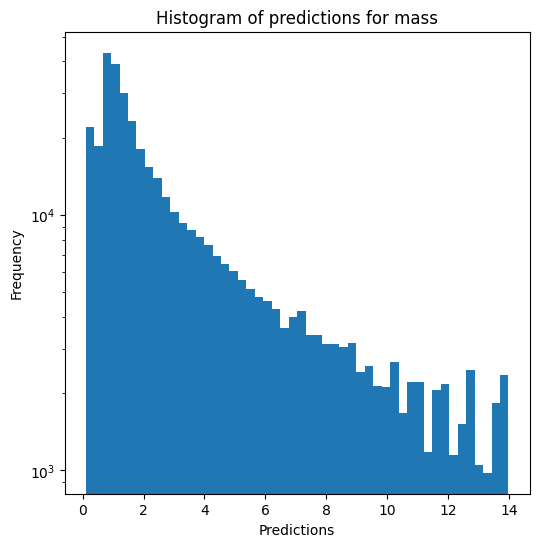

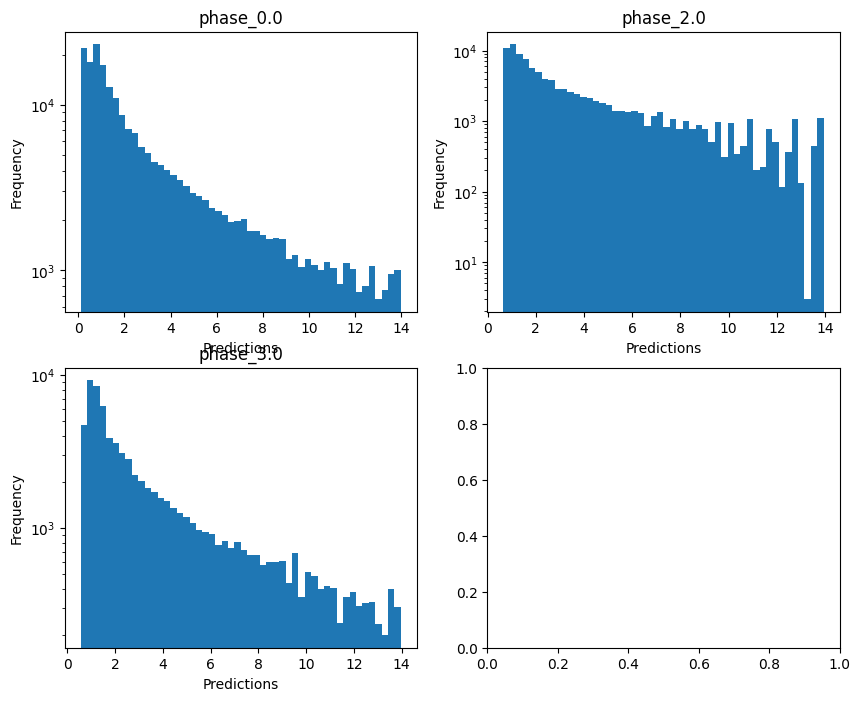

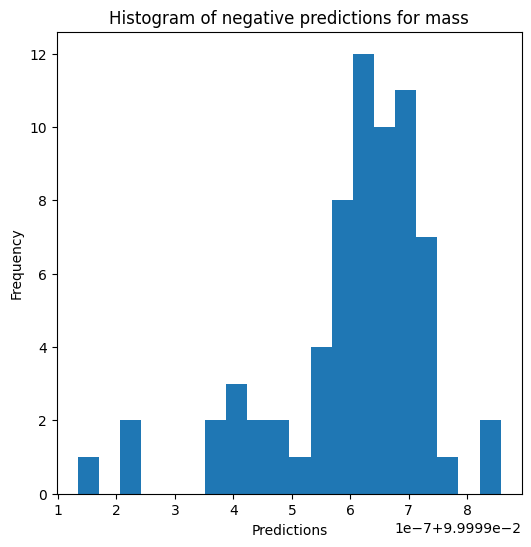


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999534137978472
  RMSE :  0.0028794315462205744
  MAE :  0.0016249901694931099
  MedAE :  0.0009003705081817026
  CORR :  0.9999767231025315
  MAX_ER :  0.14285958329850046
  Percentiles : 
    75th percentile :  0.0019340360707922888
    90th percentile :  0.0037525372191970167
    95th percentile :  0.005560942602674321
    99th percentile :  0.011331057772650891

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999185082513201
  RMSE :  0.004247330412767192
  MAE :  0.002924792575873309
  MedAE :  0.0020017498793405974
  CORR :  0.9999605620655518
  MAX_ER :  0.06636979586128344
  Percentiles : 
    75th percentile :  0.003936832214629787
    90th percentile :  0.006631573541952885
    95th percentile :  0.008763605666436726
    99th percentile :  0.014280586674303021

radius resu

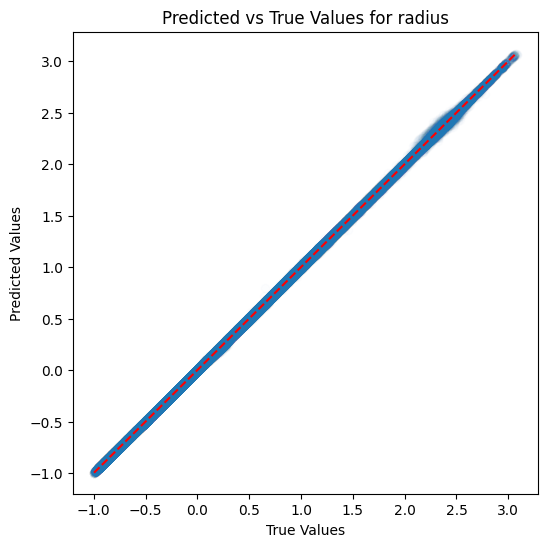

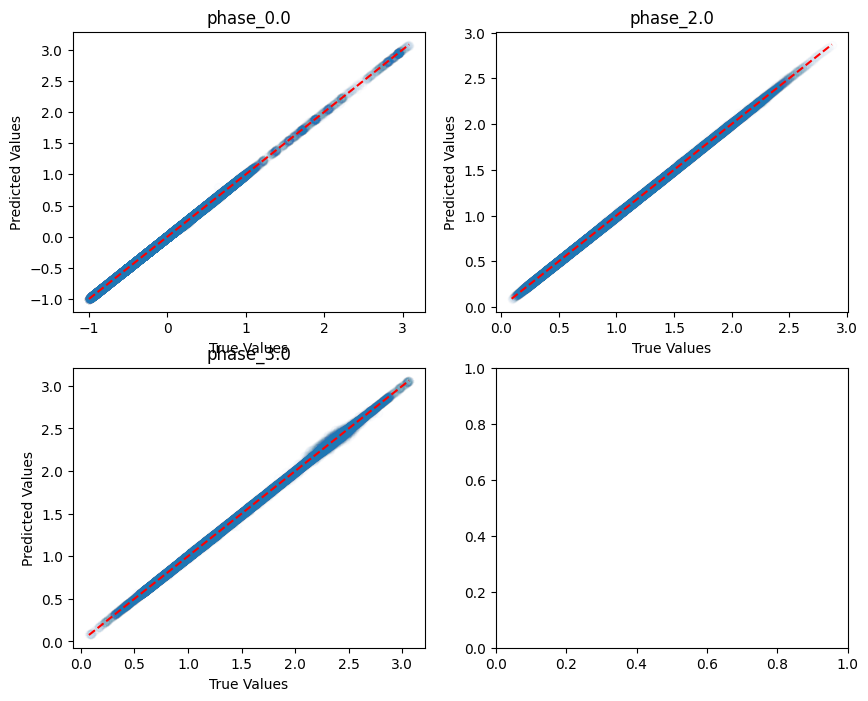

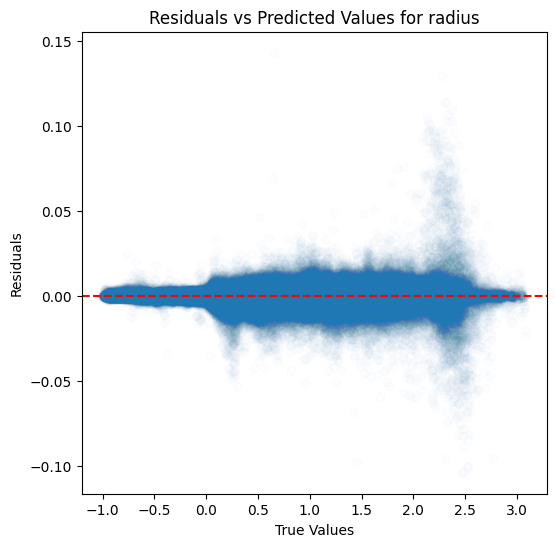

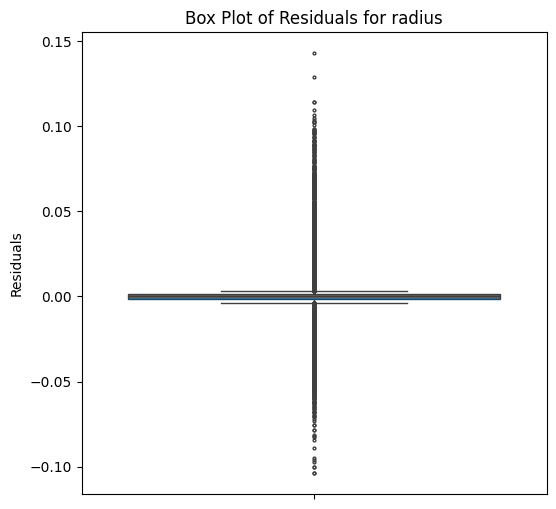

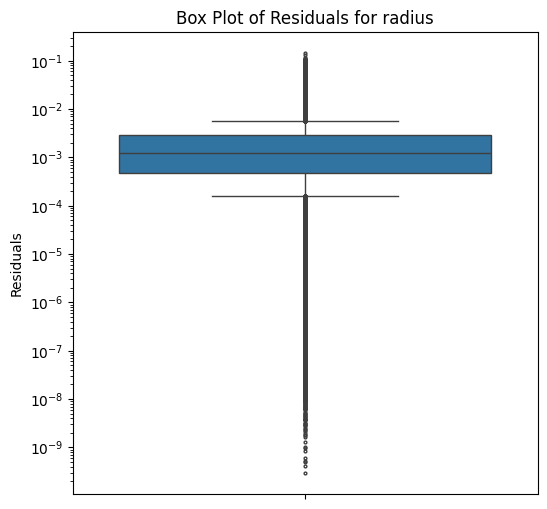

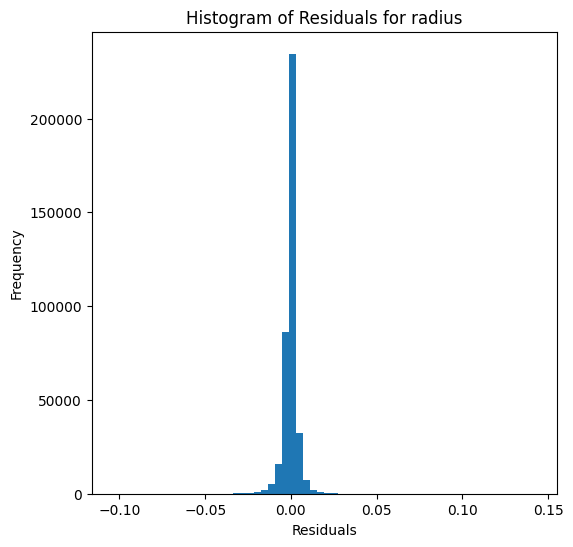

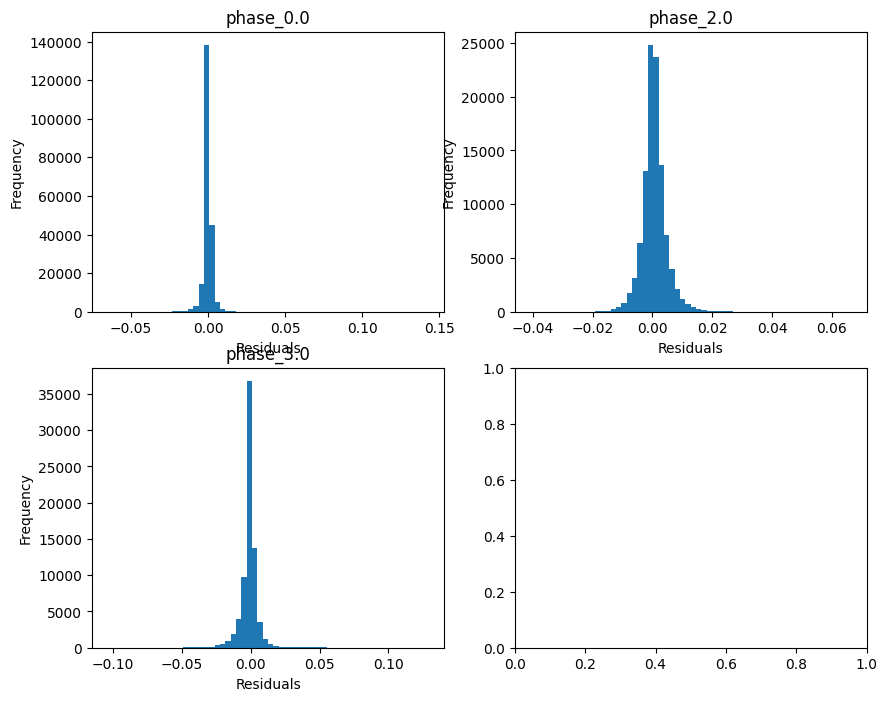

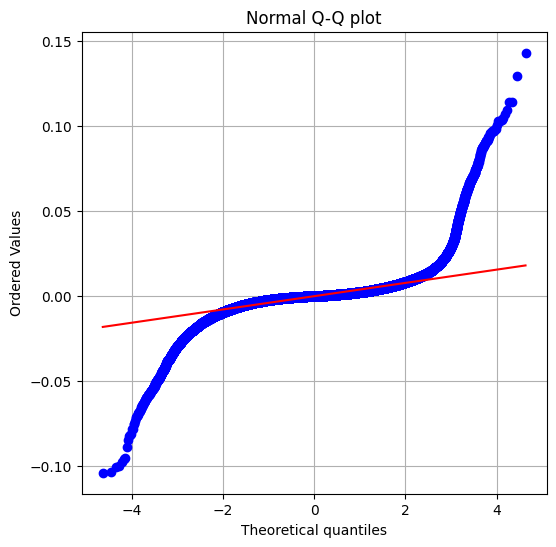

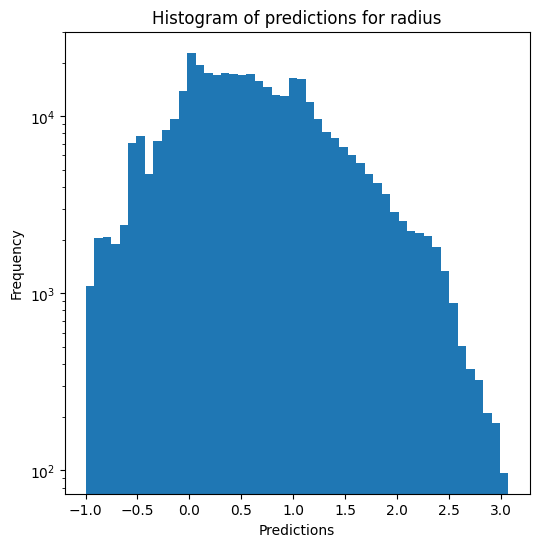

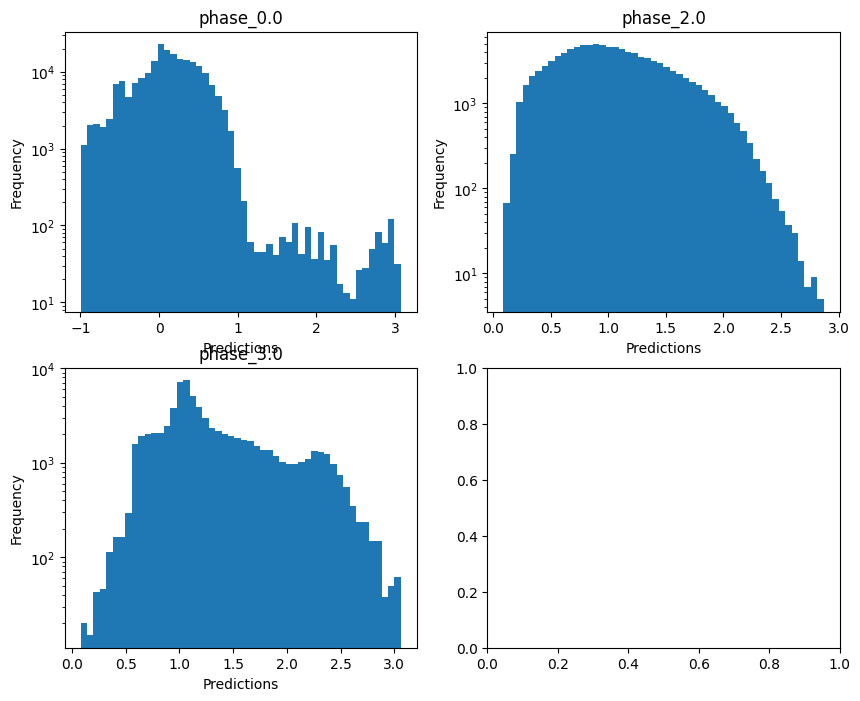

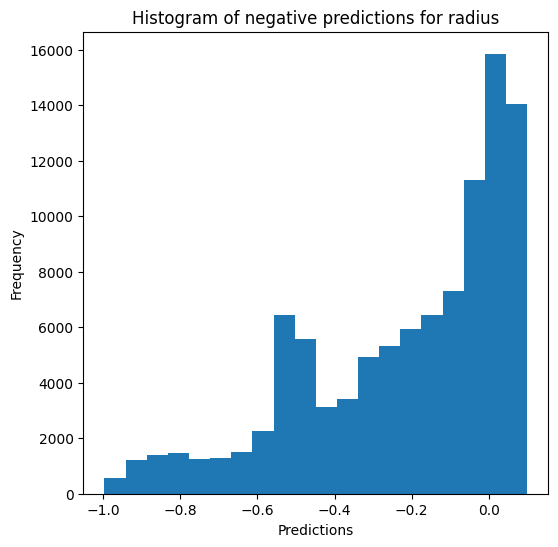

Saving results...


In [19]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### XGBoost

In [20]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9987960913520983
  RMSE :  0.11434658213908772
  MAE :  0.06394805727747928
  MedAE :  0.03172792110588221
  CORR :  0.9993979214189108
  MAX_ER :  2.5025200837731774
  Percentiles : 
    75th percentile :  0.07716485467822753
    90th percentile :  0.15608302391809956
    95th percentile :  0.2306711761476881
    99th percentile :  0.4552519058950854

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997624928648234
  RMSE :  0.051941093829585755
  MAE :  0.03575182561898714
  MedAE :  0.023734889266833203
  CORR :  0.9998867034593512
  MAX_ER :  0.5611172089068646
  Percentiles : 
    75th percentile :  0.048336958656015616
    90th percentile :  0.08245626372004439
    95th percentile :  0.10878249023563107
    99th percentile :  0

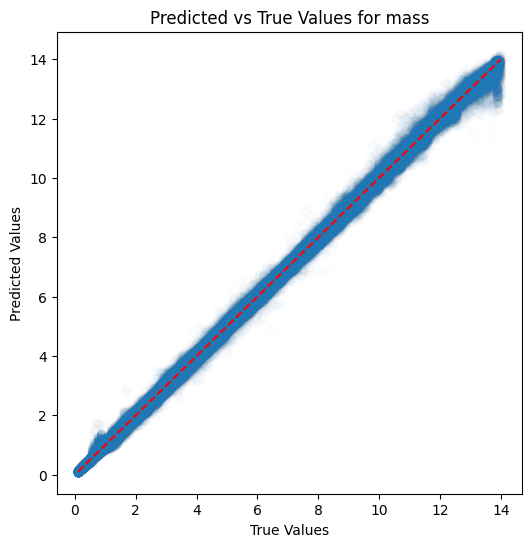

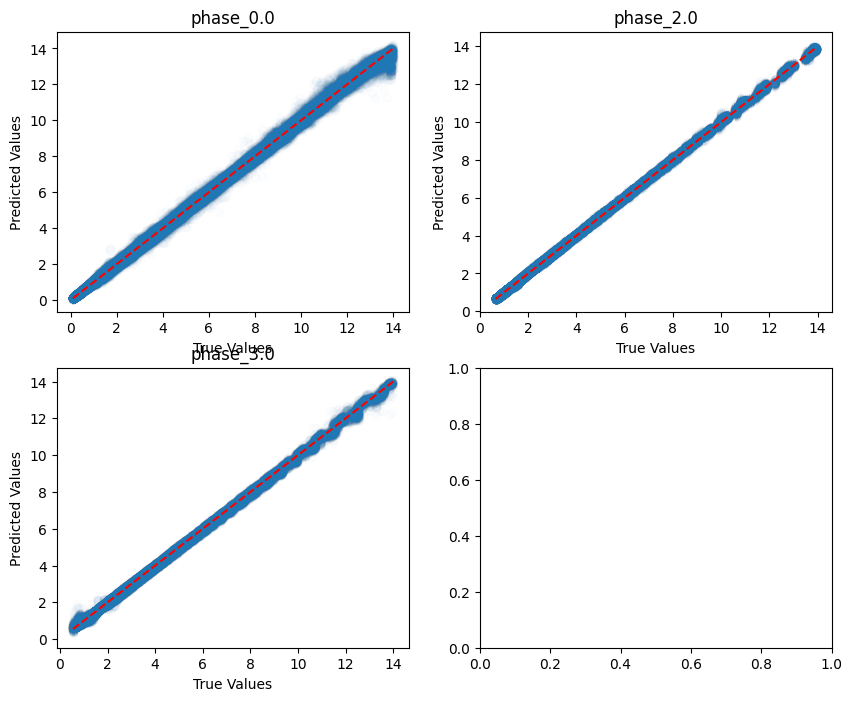

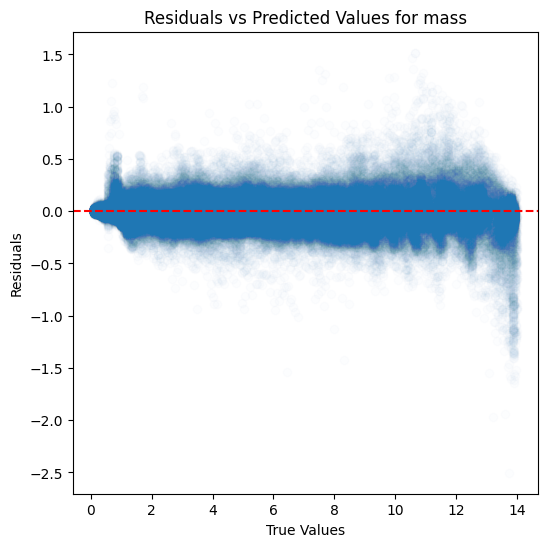

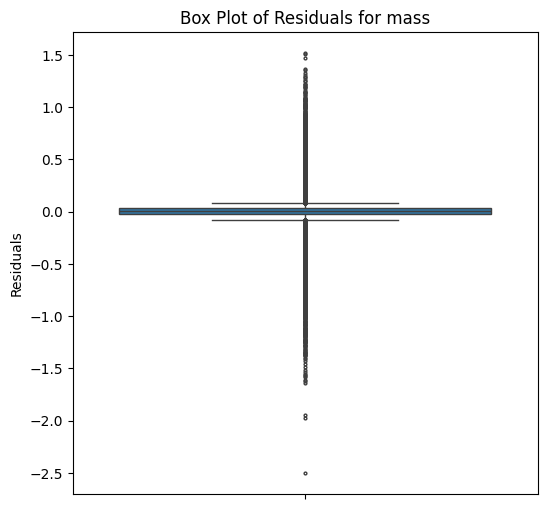

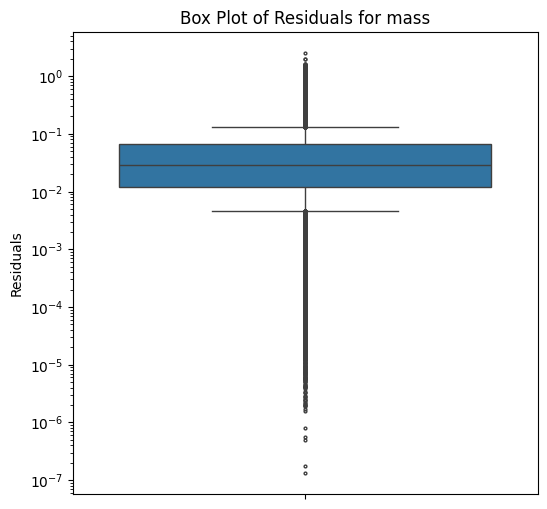

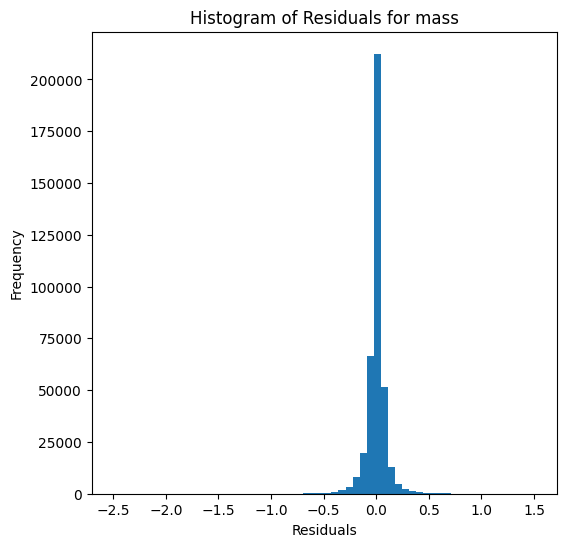

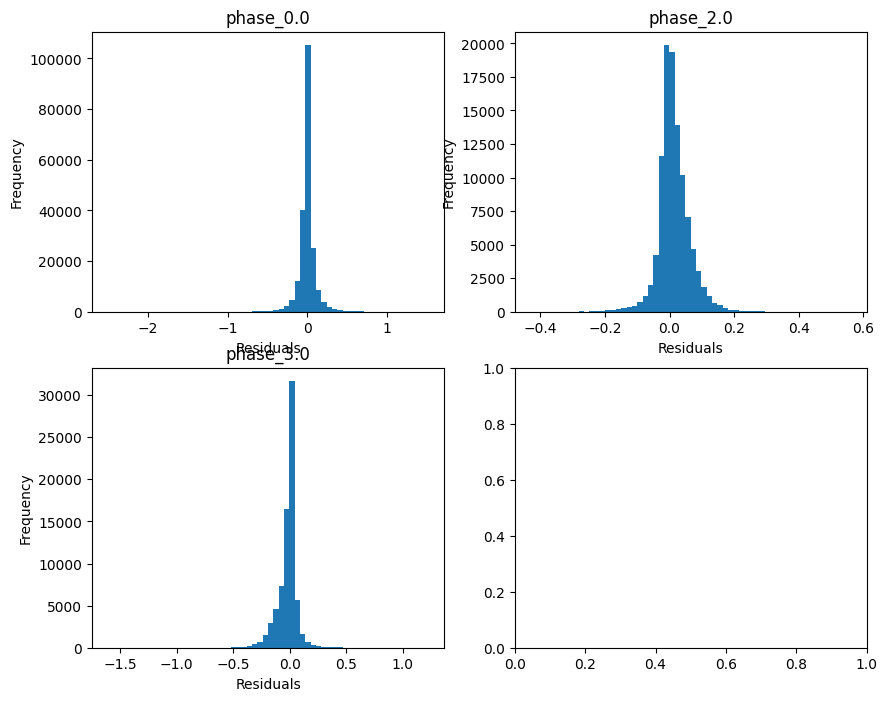

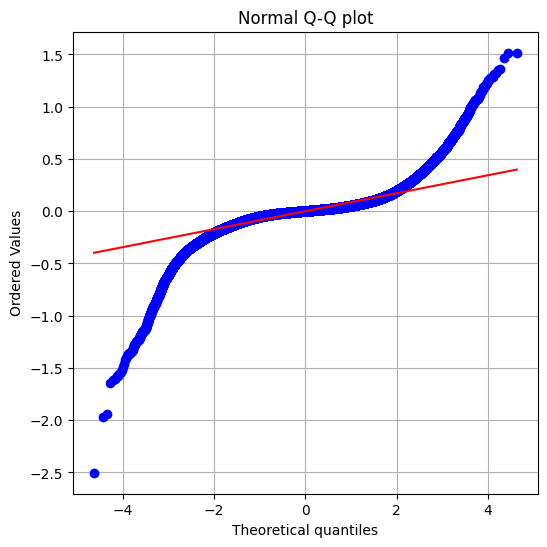

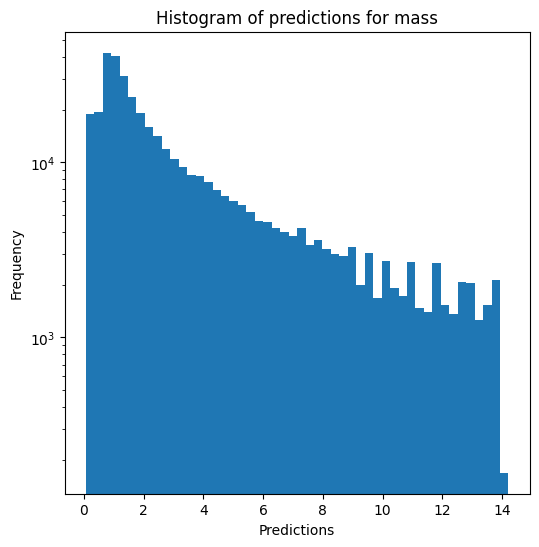

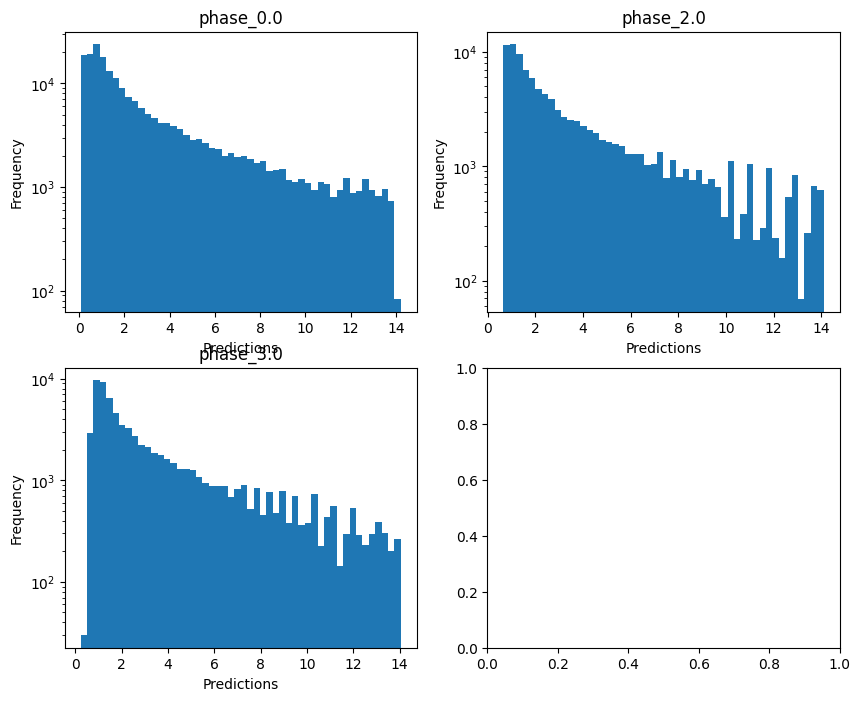

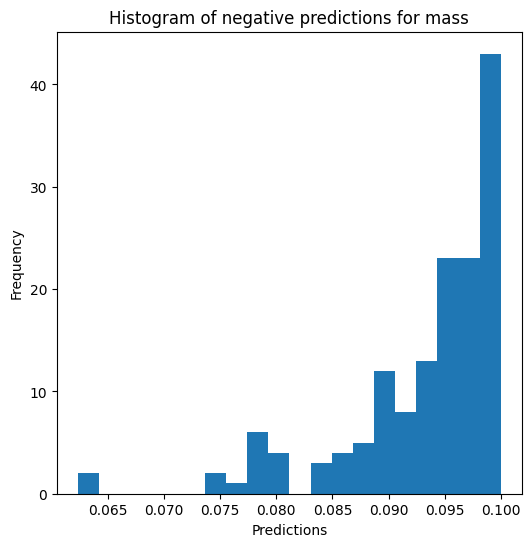


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9995117695213523
  RMSE :  0.009308623778432345
  MAE :  0.0070918946222325125
  MedAE :  0.005563829452229968
  CORR :  0.9997558778235092
  MAX_ER :  0.06512679521855912
  Percentiles : 
    75th percentile :  0.009923364817065294
    90th percentile :  0.015219711211506375
    95th percentile :  0.019041901007422337
    99th percentile :  0.027307818136555084

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9994208286577492
  RMSE :  0.011235837789302296
  MAE :  0.008731964823329752
  MedAE :  0.007094212219824814
  CORR :  0.9997106655945553
  MAX_ER :  0.0726916220901932
  Percentiles : 
    75th percentile :  0.01243773907574773
    90th percentile :  0.018355534264938723
    95th percentile :  0.022466235615986208
    99th percentile :  0.031513011492362936

radius results for

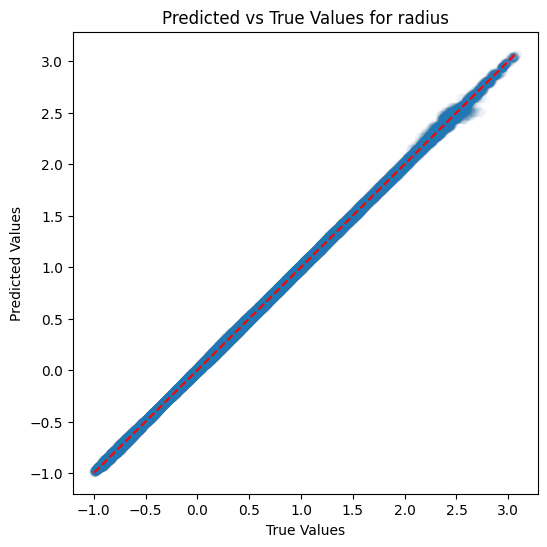

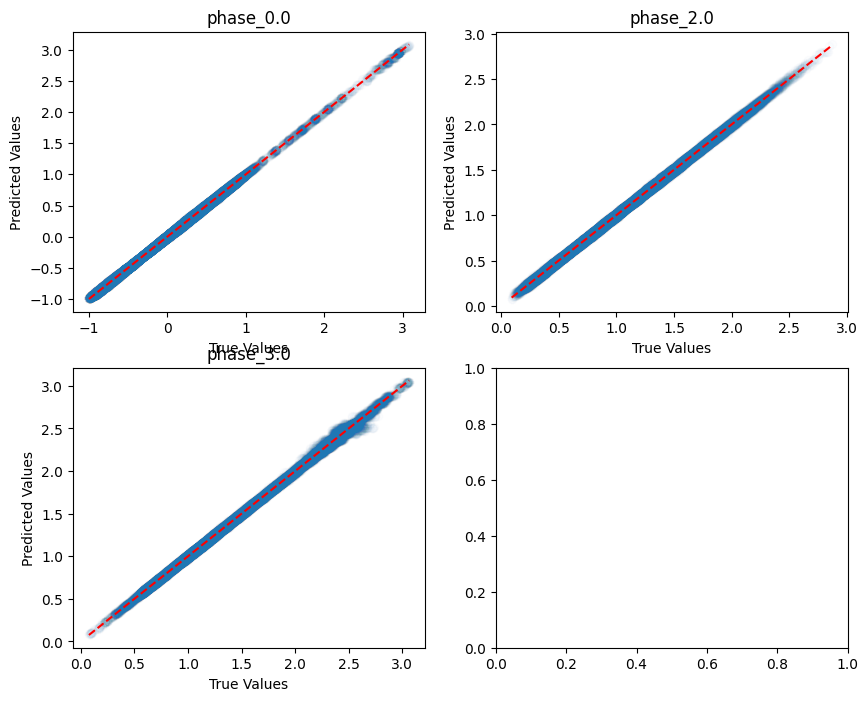

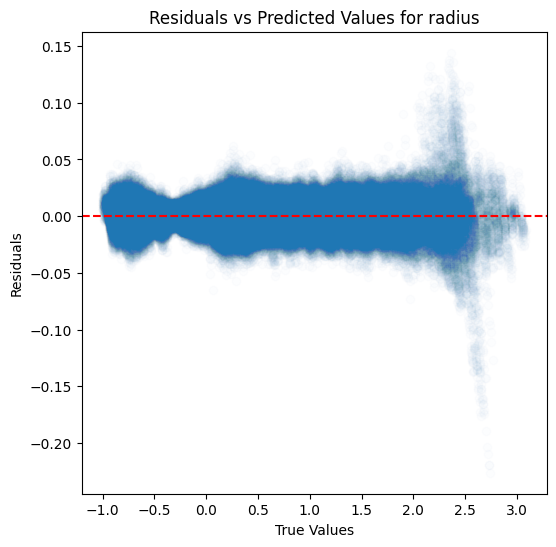

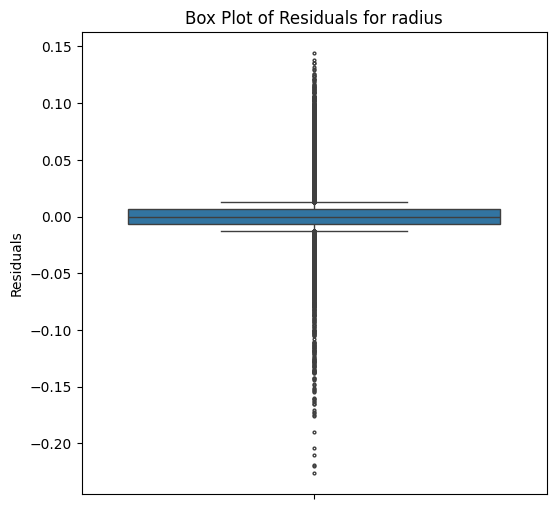

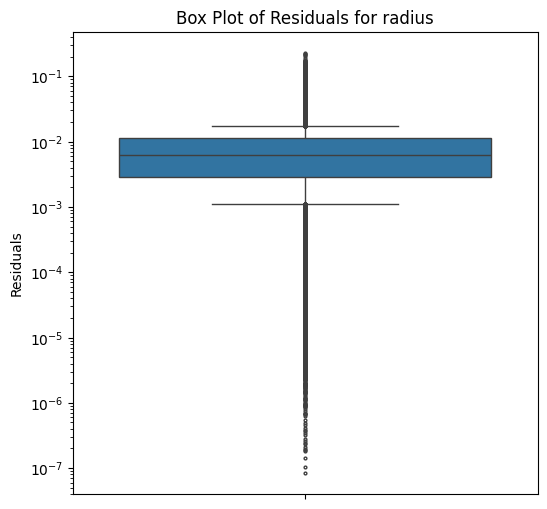

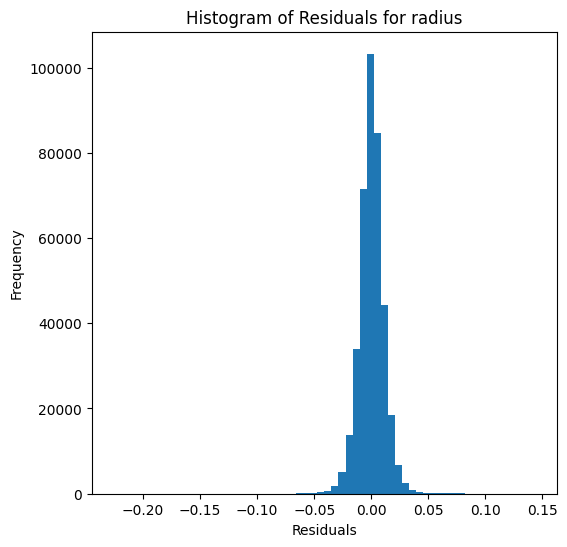

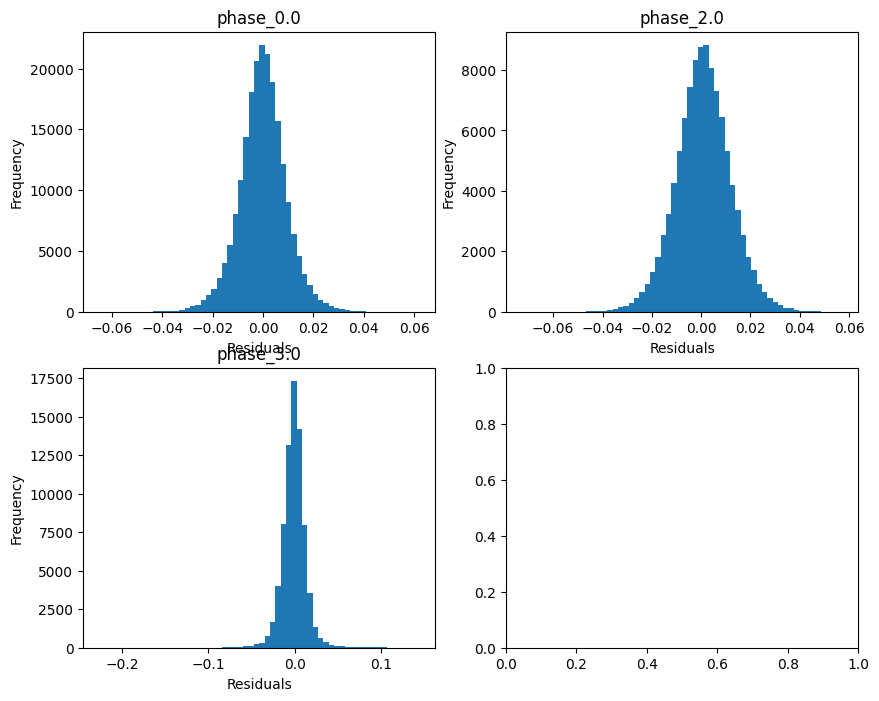

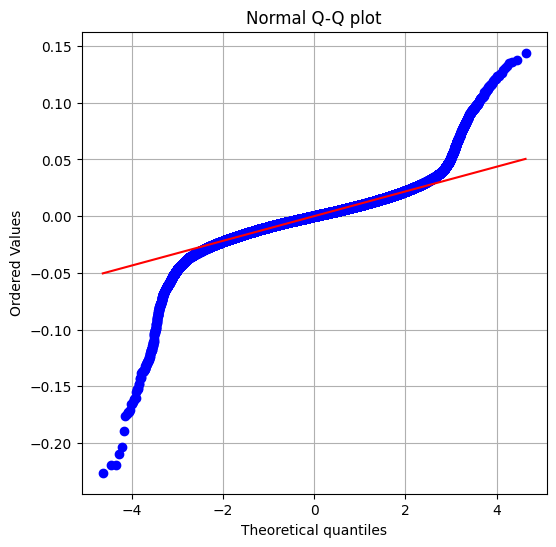

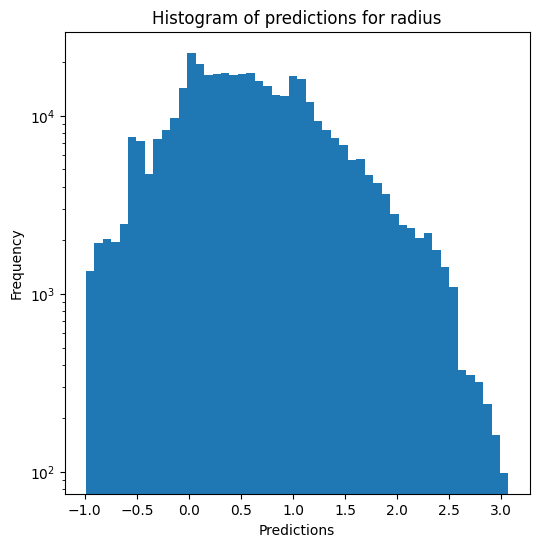

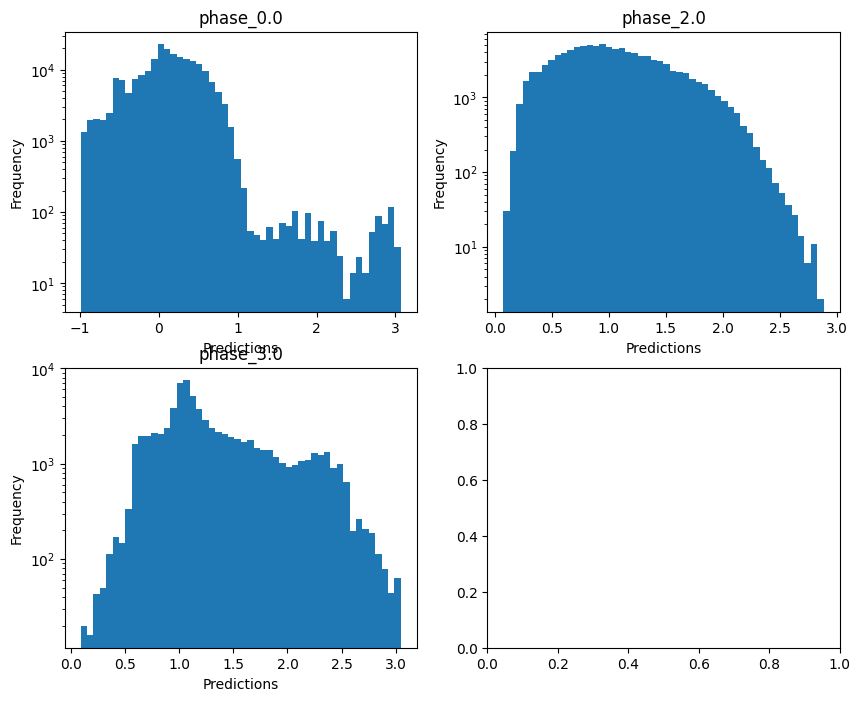

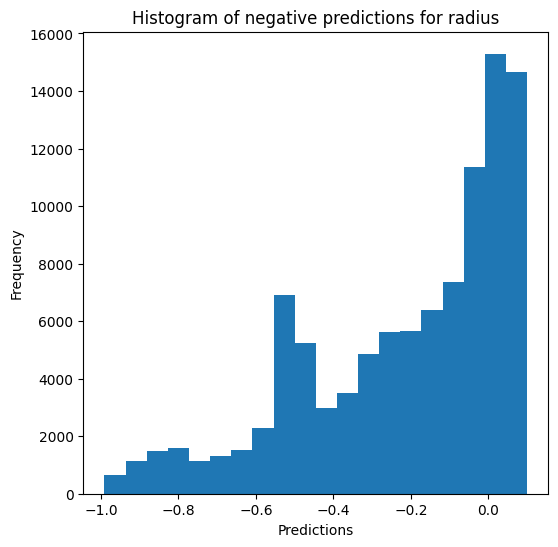

Saving results...


In [21]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### Multi-layer perceptron

In [22]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.997967880087404
  RMSE :  0.14859581485787032
  MAE :  0.06708815226689956
  MedAE :  0.03486265924300891
  CORR :  0.9989847800218492
  MAX_ER :  3.5278945091053053
  Percentiles : 
    75th percentile :  0.0742817335110062
    90th percentile :  0.14200615113723603
    95th percentile :  0.2239820281928228
    99th percentile :  0.46231533901733496

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9986994416645744
  RMSE :  0.11887744911608922
  MAE :  0.0766611055936667
  MedAE :  0.05341697740234819
  CORR :  0.9993909030531274
  MAX_ER :  1.5942654789682305
  Percentiles : 
    75th percentile :  0.09435324460808536
    90th percentile :  0.16081618324592975
    95th percentile :  0.2332319986019821
    99th percentile :  0.44523

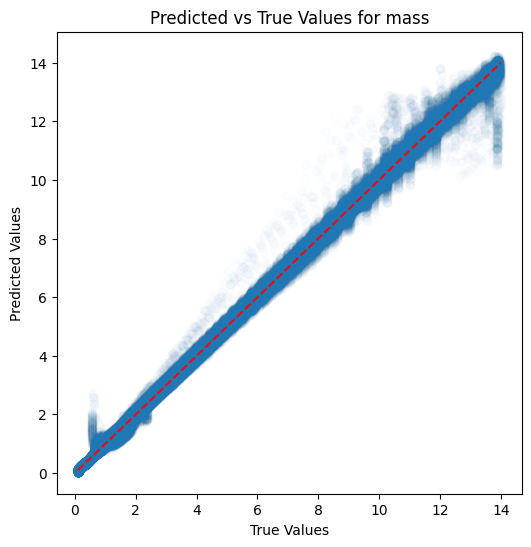

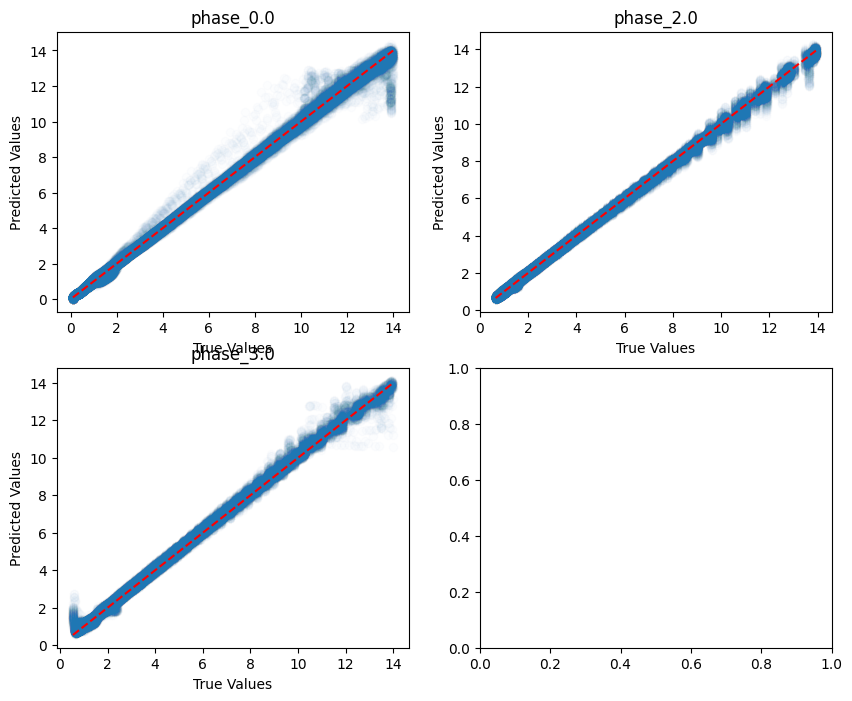

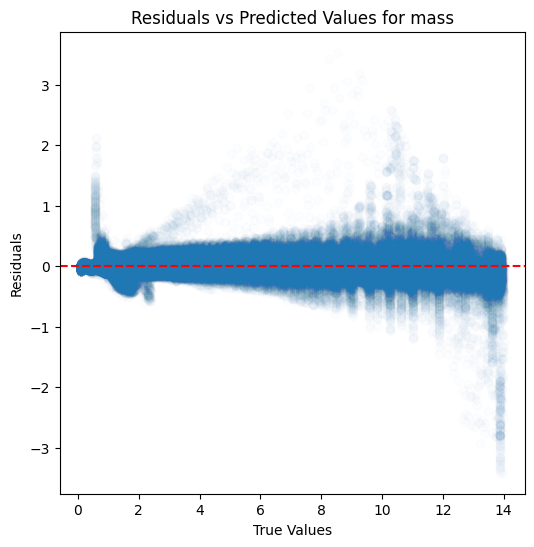

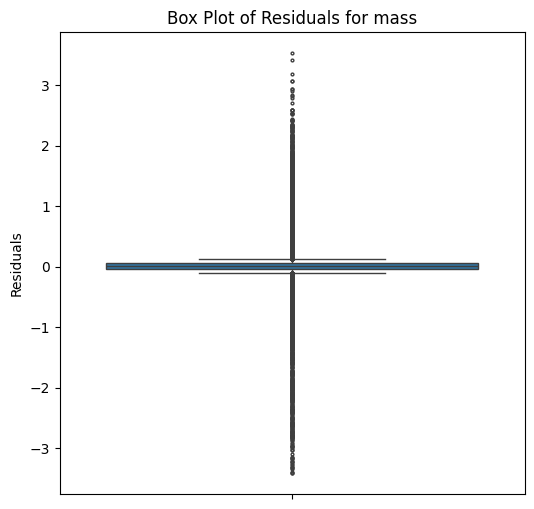

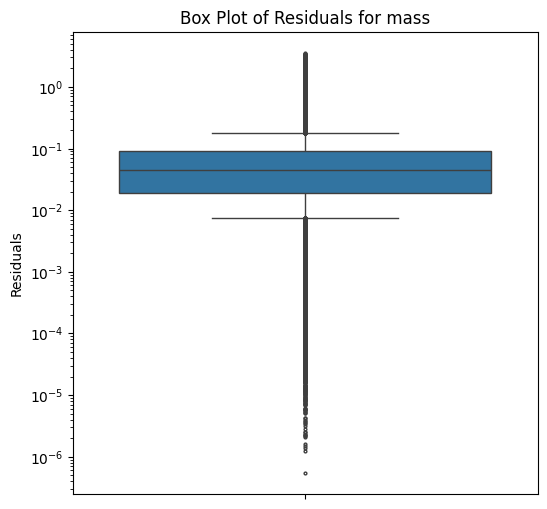

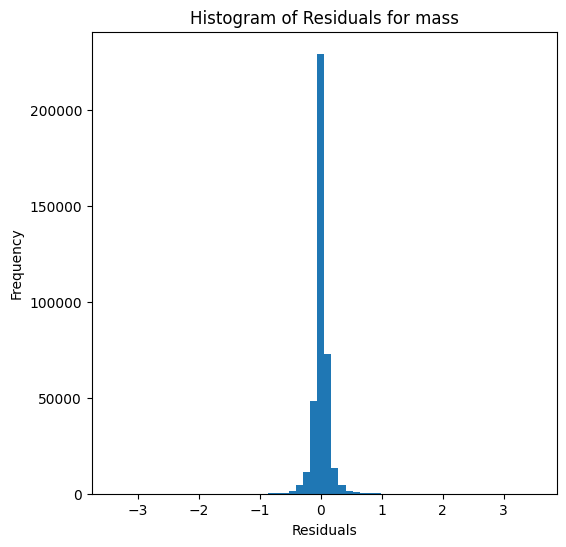

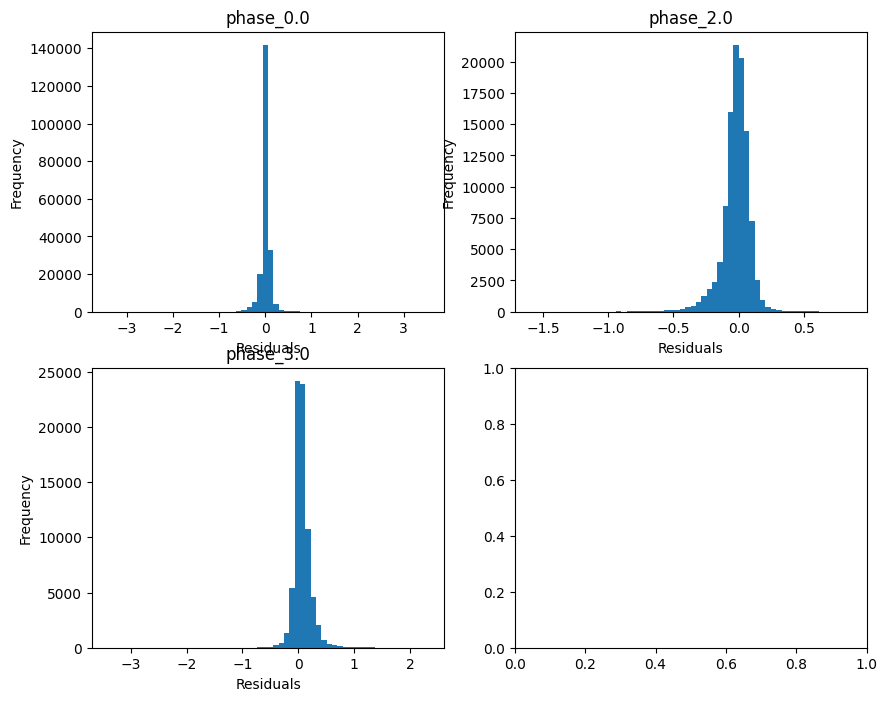

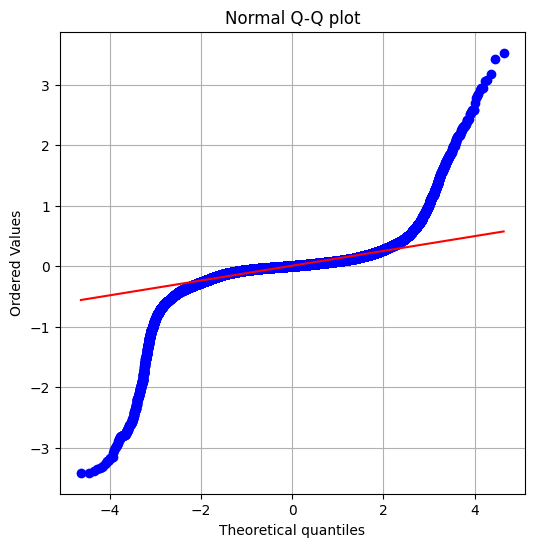

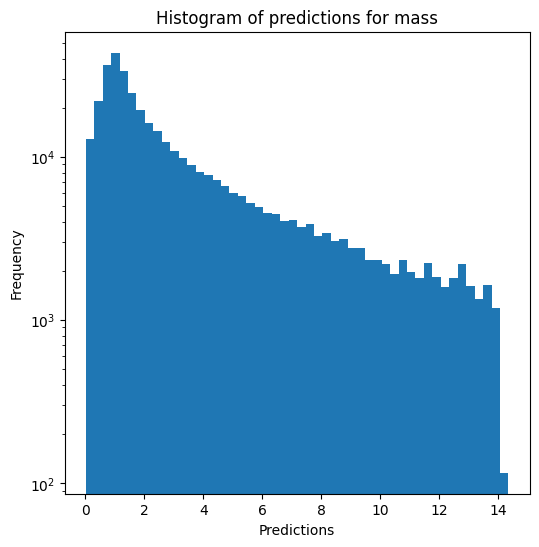

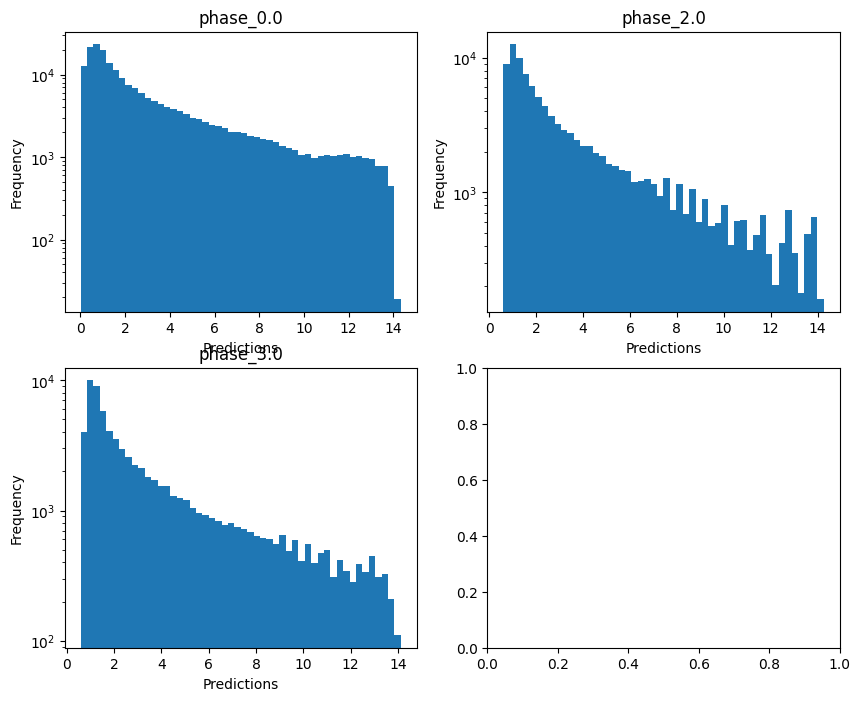

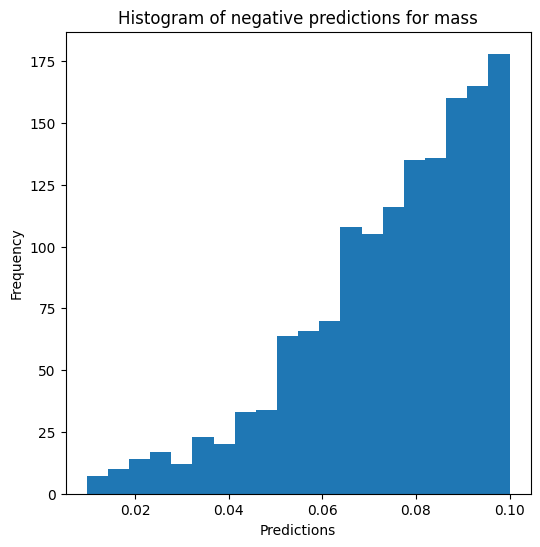


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9983627542851781
  RMSE :  0.017990998553213622
  MAE :  0.014106927888581035
  MedAE :  0.011932027985428806
  CORR :  0.9991810430555029
  MAX_ER :  0.16538346855484198
  Percentiles : 
    75th percentile :  0.01990969493010941
    90th percentile :  0.028419798277404474
    95th percentile :  0.03409135078178405
    99th percentile :  0.04871415495889766

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.998723350903017
  RMSE :  0.016657001217558965
  MAE :  0.013138349427435216
  MedAE :  0.010822745274250867
  CORR :  0.9993643661222952
  MAX_ER :  0.12369378263325004
  Percentiles : 
    75th percentile :  0.01902071920018586
    90th percentile :  0.02755262594456417
    95th percentile :  0.03291151936911937
    99th percentile :  0.04267522601729587

radius results for the ph

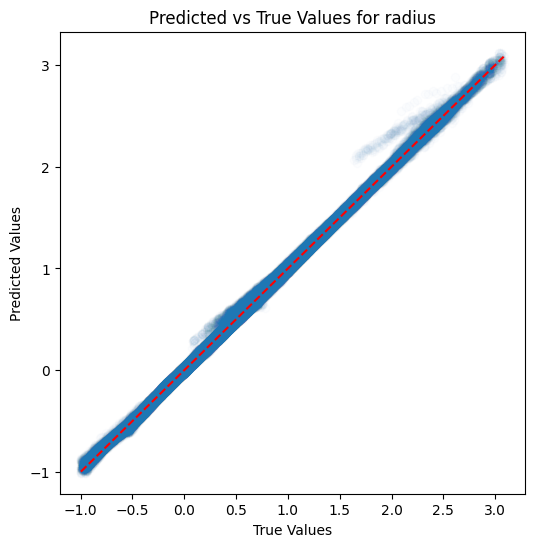

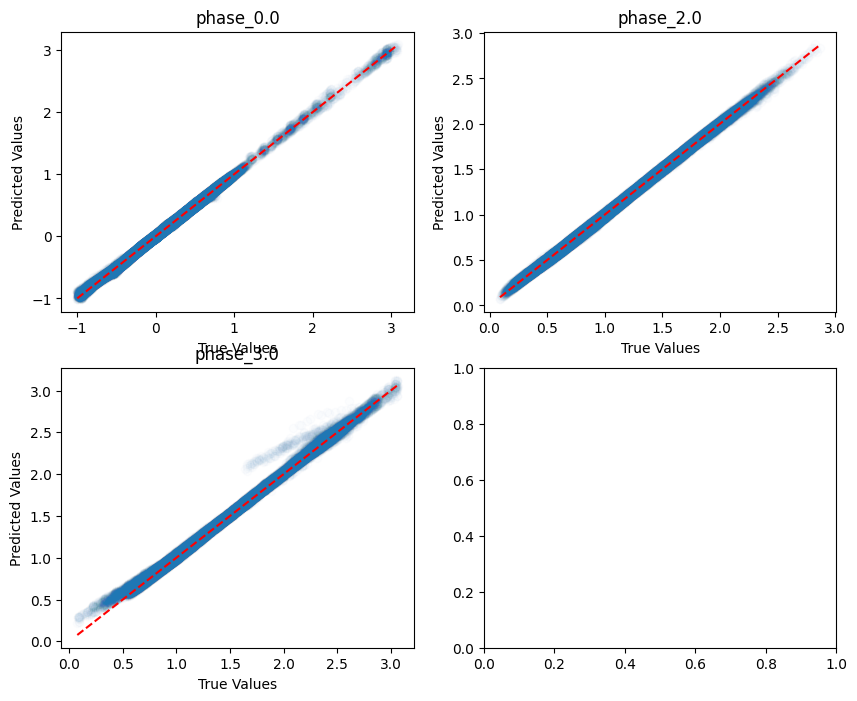

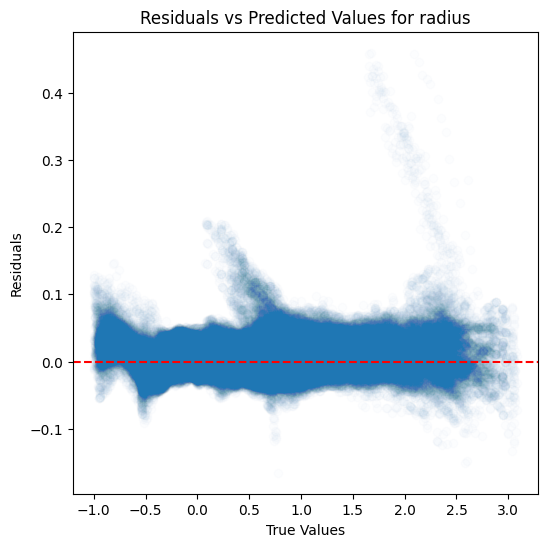

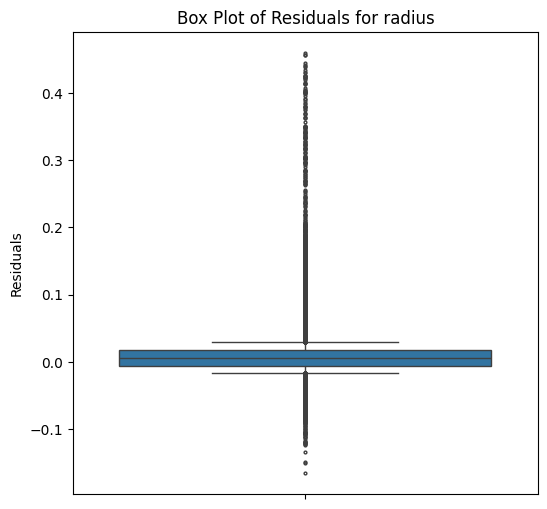

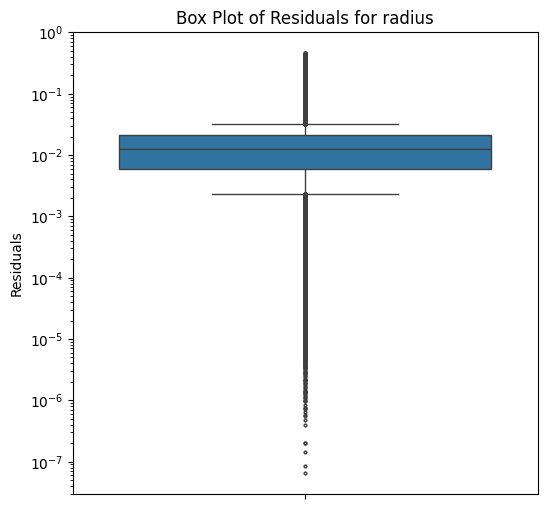

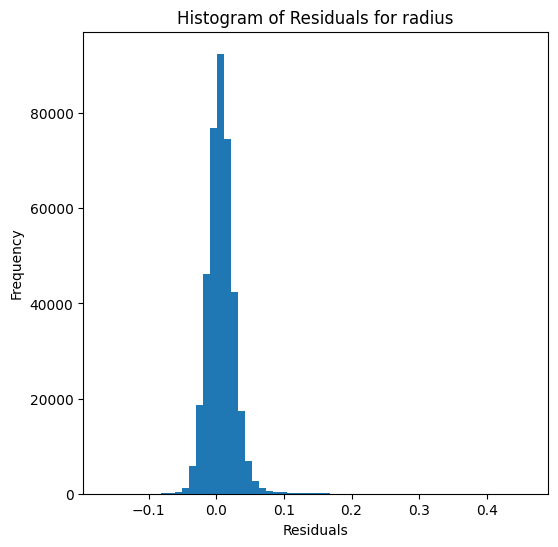

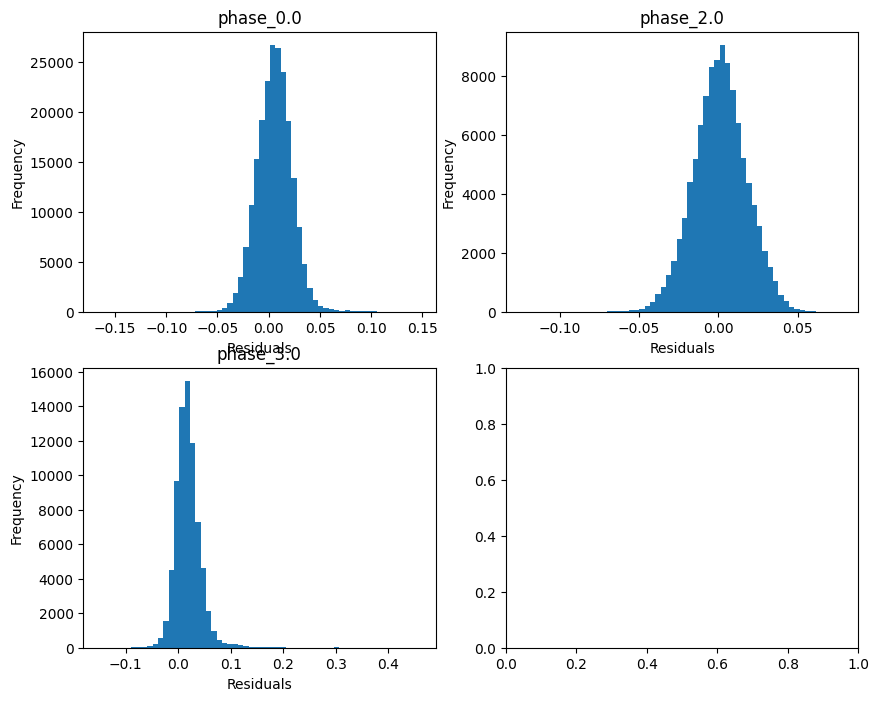

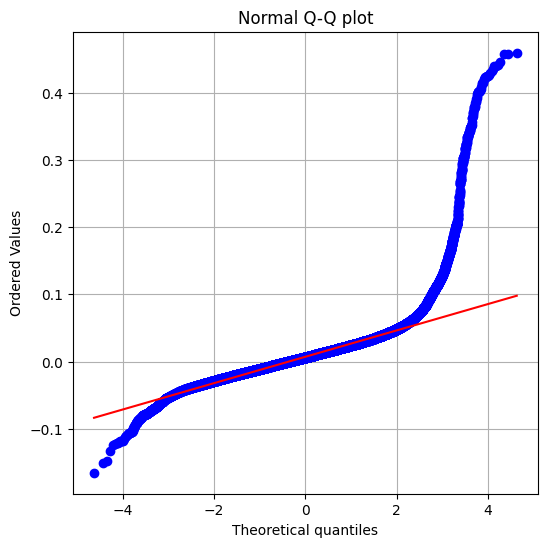

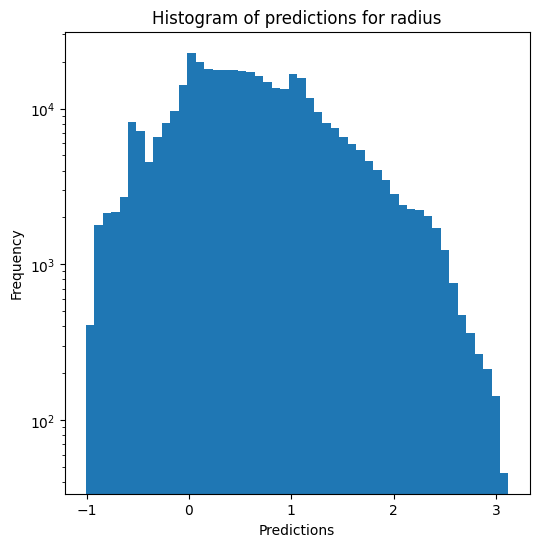

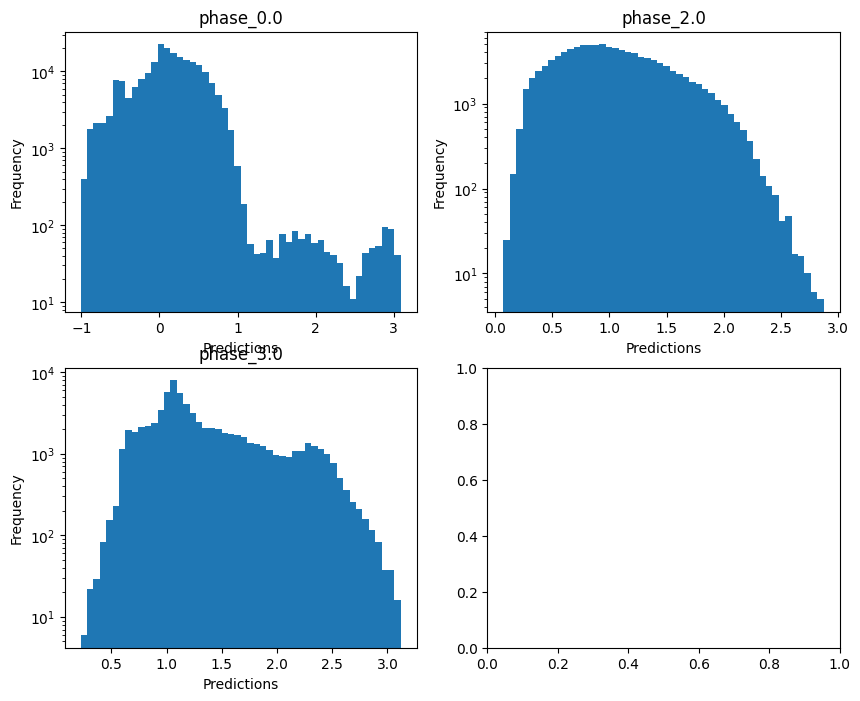

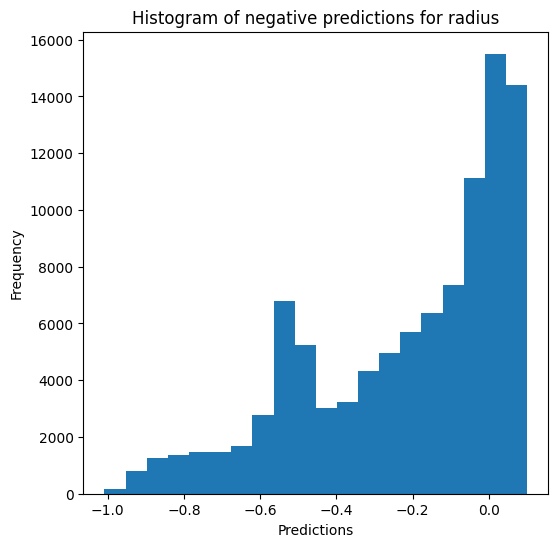

Saving results...


In [23]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, 
                                     hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)